In [1]:

# %pip install -U numpy pandas scikit-learn pyarrow tqdm matplotlib
# %pip install -U torch torchvision --index-url https://download.pytorch.org/whl/cu130
# %pip install -U transformers tokenizers safetensors

In [2]:
from __future__ import annotations

import gc
import hashlib
import html
import json
import math
import random
import re
import time
import unicodedata
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Iterator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, roc_auc_score
from torch.utils.data import DataLoader, Dataset, Sampler, Subset
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 240)
torch.set_float32_matmul_precision("high")

D:\dev\projects\zhere_olap\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
@dataclass
class Config:
    DATA_DIR: Path = Path(r"D:\dev\projects\datasets_collection\data\kuairand_adapted")
    OUTPUT_ROOT: Path = Path(r"D:\dev\projects\datasets_collection\outputs_sfg_bicross")
    TEXT_CACHE_DIR: Path = Path(r"D:\datasets\KuaiRand\KuaiRand-Pure\text_cache_final")

    MODEL_MODE: str = "paper_no_id"  # hybrid_max_accuracy / paper_no_id
    RUN_TAG: str = "sfg_bicross_final"
    SEEDS: tuple[int, ...] = (2026,)

    MACBERT_MODEL: str = "hfl/chinese-macbert-base"
    CLEANING_VERSION: str = "clean_v2_nfkc_url_mention_hashtag_category"
    MACBERT_BATCH_SIZE: int = 96
    CAPTION_MAX_LENGTH: int = 96
    COVER_MAX_LENGTH: int = 48
    CATEGORY_MAX_LENGTH: int = 40

    ACTIVE_DEGREES: tuple[str, ...] = ("high_active", "full_active")
    MIN_TRAIN_INTERACTIONS: int = 30
    MIN_TRAIN_UNIQUE_ITEMS: int = 20
    MIN_TRAIN_POSITIVES: int = 5

    D_MODEL: int = 512
    NUM_HEADS: int = 8
    SELF_ATTENTION_LAYERS: int = 2
    CROSS_ATTENTION_LAYERS: int = 1
    FFN_DIM: int = 2048
    ATTENTION_DROPOUT: float = 0.08
    MODEL_DROPOUT: float = 0.12
    FIELD_DROPOUT: float = 0.05
    FIELD_GATE_REDUCTION: int = 4
    QK_TEMPERATURE_INIT: float = 5.0
    QK_TEMPERATURE_MIN: float = 1.0
    QK_TEMPERATURE_MAX: float = 20.0

    MAX_HISTORY: int = 30
    HISTORY_ATTENTION_HIDDEN: int = 256

    DCN_LAYERS: int = 2
    DCN_RANK: int = 64
    DEEP_HIDDEN: tuple[int, ...] = (512, 256)

    ID_DIM: int = 128
    ID_DROPOUT: float = 0.10

    BCE_WEIGHT: float = 1.0
    PAIRWISE_WEIGHT: float = 0.40
    STRONG_ACTION_WEIGHT: float = 0.20
    LONG_VIEW_WEIGHT: float = 0.15
    CLICK_WEIGHT: float = 0.05
    MAX_PAIRWISE_PAIRS_PER_USER: int = 128
    MAX_POS_WEIGHT: float = 15.0

    BATCH_SIZE: int = 64
    TRAIN_EVENTS_PER_USER_PER_BATCH: int = 16
    GRADIENT_ACCUMULATION_STEPS: int = 1
    EPOCHS: int = 15
    LEARNING_RATE: float = 1.5e-4
    ID_LEARNING_RATE: float = 5e-4
    WEIGHT_DECAY: float = 1e-4
    WARMUP_RATIO: float = 0.05
    GRADIENT_CLIP_NORM: float = 1.0
    EARLY_STOPPING_PATIENCE: int = 3
    EARLY_STOPPING_MIN_DELTA: float = 1e-4
    PRIMARY_METRIC: str = "NDCG@10"
    USE_AMP: bool = True
    USE_TORCH_COMPILE: bool = False

    NUM_WORKERS: int = 0
    DEDUPLICATE_EVENTS: bool = True

    DEBUG_MODE: bool = False
    DEBUG_USER_COUNT: int = 1200
    DEBUG_TRAIN_MAX_EVENTS: int = 100_000
    DEBUG_EPOCHS: int = 3
    RUN_SMALL_OVERFIT_CHECK: bool = False
    SMALL_OVERFIT_SIZE: int = 4096
    SMALL_OVERFIT_EPOCHS: int = 8

CFG = Config()

if CFG.MODEL_MODE not in {"hybrid_max_accuracy", "paper_no_id"}:
    raise ValueError("MODEL_MODE 必须是 hybrid_max_accuracy 或 paper_no_id")
if CFG.D_MODEL % CFG.NUM_HEADS != 0:
    raise ValueError("D_MODEL 必须能被 NUM_HEADS 整除")
if CFG.BATCH_SIZE < CFG.TRAIN_EVENTS_PER_USER_PER_BATCH:
    raise ValueError("BATCH_SIZE 不能小于 TRAIN_EVENTS_PER_USER_PER_BATCH")

USE_ID_BRANCH = CFG.MODEL_MODE == "hybrid_max_accuracy"
CFG.OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
CFG.TEXT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(json.dumps(
    {k: str(v) if isinstance(v, Path) else v for k, v in asdict(CFG).items()},
    ensure_ascii=False,
    indent=2,
))
print("USE_ID_BRANCH:", USE_ID_BRANCH)

{
  "DATA_DIR": "D:\\dev\\projects\\datasets_collection\\data\\kuairand_adapted",
  "OUTPUT_ROOT": "D:\\dev\\projects\\datasets_collection\\outputs_sfg_bicross",
  "TEXT_CACHE_DIR": "D:\\datasets\\KuaiRand\\KuaiRand-Pure\\text_cache_final",
  "MODEL_MODE": "paper_no_id",
  "RUN_TAG": "sfg_bicross_final",
  "SEEDS": [
    2026
  ],
  "MACBERT_MODEL": "hfl/chinese-macbert-base",
  "CLEANING_VERSION": "clean_v2_nfkc_url_mention_hashtag_category",
  "MACBERT_BATCH_SIZE": 96,
  "CAPTION_MAX_LENGTH": 96,
  "COVER_MAX_LENGTH": 48,
  "CATEGORY_MAX_LENGTH": 40,
  "ACTIVE_DEGREES": [
    "high_active",
    "full_active"
  ],
  "MIN_TRAIN_INTERACTIONS": 30,
  "MIN_TRAIN_UNIQUE_ITEMS": 20,
  "MIN_TRAIN_POSITIVES": 5,
  "D_MODEL": 512,
  "NUM_HEADS": 8,
  "SELF_ATTENTION_LAYERS": 2,
  "CROSS_ATTENTION_LAYERS": 1,
  "FFN_DIM": 2048,
  "ATTENTION_DROPOUT": 0.08,
  "MODEL_DROPOUT": 0.12,
  "FIELD_DROPOUT": 0.05,
  "FIELD_GATE_REDUCTION": 4,
  "QK_TEMPERATURE_INIT": 5.0,
  "QK_TEMPERATURE_MIN": 1.0,
  

In [4]:
#random seed/device/混合精度

In [5]:
#
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(CFG.USE_AMP and DEVICE.type == "cuda")

if DEVICE.type == "cuda" and torch.cuda.is_bf16_supported():
    AMP_DTYPE = torch.bfloat16
else:
    AMP_DTYPE = torch.float16

print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
    print("BF16 supported:", torch.cuda.is_bf16_supported())
print("AMP:", USE_AMP, "AMP_DTYPE:", AMP_DTYPE)

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
CUDA: 13.0
BF16 supported: True
AMP: True AMP_DTYPE: torch.bfloat16


In [6]:
#file check and read data

In [7]:
FILES = {
    "users": CFG.DATA_DIR / "user_features_pure.csv",
    "items": CFG.DATA_DIR / "video_features_basic_pure.csv",
    "train_log": CFG.DATA_DIR / "log_standard_4_08_to_4_21_pure.csv",  # adapted from log_standard_train_pure.csv
    "val_log": CFG.DATA_DIR / "log_standard_4_22_to_5_08_pure.csv",  # adapted from log_standard_val_pure.csv
    "test_log": CFG.DATA_DIR / "log_random_4_22_to_5_08_pure.csv",  # adapted from log_random_test_pure.csv
    "captions": CFG.DATA_DIR / "kuairand_video_captions.csv",
    "categories": CFG.DATA_DIR / "kuairand_video_categories.csv",
}

missing_files = [str(path) for path in FILES.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError("缺少数据文件:\n" + "\n".join(missing_files))

for name, path in FILES.items():
    print(f"{name:>12}: {path.name} | {path.stat().st_size / 1024**2:,.2f} MB")

LOG_REQUIRED_COLUMNS = [
    "user_id", "video_id", "date", "time_ms",
    "is_click", "long_view", "is_like", "is_follow",
    "is_comment", "is_forward", "is_hate",
    "play_time_ms", "duration_ms",
]

users_raw = pd.read_csv(FILES["users"], low_memory=False)
items_basic = pd.read_csv(FILES["items"], low_memory=False)
train_log_raw = pd.read_csv(
    FILES["train_log"], usecols=LOG_REQUIRED_COLUMNS, low_memory=False
)
val_log_raw = pd.read_csv(
    FILES["val_log"], usecols=LOG_REQUIRED_COLUMNS, low_memory=False
)
test_log_raw = pd.read_csv(
    FILES["test_log"], usecols=LOG_REQUIRED_COLUMNS, low_memory=False
)

if not users_raw["user_id"].is_unique:
    raise ValueError("user_features_pure.csv 中 user_id 不唯一")
if not items_basic["video_id"].is_unique:
    raise ValueError("video_features_basic_pure.csv 中 video_id 不唯一")

print("users_raw:", users_raw.shape)
print("items_basic:", items_basic.shape)
print("train_log_raw:", train_log_raw.shape)
print("val_log_raw:", val_log_raw.shape)
print("test_log_raw:", test_log_raw.shape)

       users: user_features_pure.csv | 8.33 MB
       items: video_features_basic_pure.csv | 48.03 MB
   train_log: log_standard_4_08_to_4_21_pure.csv | 20.05 MB
     val_log: log_standard_4_22_to_5_08_pure.csv | 4.28 MB
    test_log: log_random_4_22_to_5_08_pure.csv | 7.33 MB
    captions: kuairand_video_captions.csv | 19.64 MB
  categories: kuairand_video_categories.csv | 2.22 MB
users_raw: (6006, 129)
items_basic: (39000, 107)
train_log_raw: (334177, 13)
val_log_raw: (71335, 13)
test_log_raw: (120084, 13)


In [8]:
#read  supply Caption and Category

In [9]:
def read_relevant_supplement(
    path: Path,
    usecols: list[str],
    needed_video_ids: set[int],
    chunksize: int = 250_000,
) -> pd.DataFrame:
    if not needed_video_ids:
        raise ValueError("needed_video_ids 为空")

    max_video_id = max(needed_video_ids)
    fast_rows = max_video_id + 1

    try:
        frame = pd.read_csv(
            path,
            usecols=usecols,
            nrows=fast_rows,
            low_memory=False,
        )
        frame["final_video_id"] = pd.to_numeric(
            frame["final_video_id"], errors="coerce"
        )
        frame = frame.dropna(subset=["final_video_id"]).copy()
        frame["final_video_id"] = frame["final_video_id"].astype("int64")
        selected = frame[frame["final_video_id"].isin(needed_video_ids)].copy()
    except Exception as error:
        print("快速读取失败，改用分块扫描：", repr(error))
        selected = pd.DataFrame(columns=usecols)

    coverage = selected["final_video_id"].nunique() if len(selected) else 0
    if coverage < len(needed_video_ids):
        print(
            f"{path.name}: 快速读取覆盖 {coverage}/{len(needed_video_ids)}，"
            "回退为分块扫描。"
        )
        chunks = []
        for chunk in pd.read_csv(
            path,
            usecols=usecols,
            chunksize=chunksize,
            low_memory=False,
        ):
            ids = pd.to_numeric(chunk["final_video_id"], errors="coerce")
            keep = ids.isin(needed_video_ids)
            if keep.any():
                part = chunk.loc[keep].copy()
                part["final_video_id"] = ids.loc[keep].astype("int64")
                chunks.append(part)
        if not chunks:
            raise ValueError(f"{path.name} 未找到任何 Pure video_id")
        selected = pd.concat(chunks, ignore_index=True)

    selected = selected.drop_duplicates("final_video_id", keep="last")
    missing = needed_video_ids - set(selected["final_video_id"].tolist())
    print(
        f"{path.name}: selected={len(selected):,}, "
        f"coverage={1 - len(missing) / max(len(needed_video_ids), 1):.2%}"
    )
    return selected.reset_index(drop=True)

needed_video_ids = set(
    pd.to_numeric(items_basic["video_id"], errors="coerce")
    .dropna().astype("int64").tolist()
)

captions = read_relevant_supplement(
    FILES["captions"],
    ["final_video_id", "caption", "show_cover_text", "duration"],
    needed_video_ids,
)

CATEGORY_COLUMNS = [
    "final_video_id",
    "first_level_category_id",
    "first_level_category_name",
    "first_level_category_prob",
    "second_level_category_id",
    "second_level_category_name",
    "second_level_category_prob",
    "third_level_category_id",
    "third_level_category_name",
    "third_level_category_prob",
    "fourth_level_category_id",
    "fourth_level_category_name",
    "fourth_level_category_prob",
]
categories = read_relevant_supplement(
    FILES["categories"],
    CATEGORY_COLUMNS,
    needed_video_ids,
)

kuairand_video_captions.csv: selected=39,000, coverage=100.00%
kuairand_video_categories.csv: selected=39,000, coverage=100.00%


In [10]:
#clean text /merge item

In [11]:
MISSING_TEXT_VALUES = {
    "", "nan", "none", "null", "<na>", "unknown", "-124", "-124.0"
}

URL_RE = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
HTML_TAG_RE = re.compile(r"<[^>]+>")
ACCOUNT_RE = re.compile(r"@\S*?\([A-Za-z]\d+\)")
CONTROL_RE = re.compile(r"[\x00-\x1f\x7f-\x9f]")
SPACE_RE = re.compile(r"\s+")
REPEATED_PUNCT_RE = re.compile(r"([!！?？。,.，；;：:])\1+")

def clean_chinese_text(value: Any) -> str:
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKC", html.unescape(str(value)))
    if text.strip().lower() in MISSING_TEXT_VALUES:
        return ""
    text = URL_RE.sub(" ", text)
    text = HTML_TAG_RE.sub(" ", text)
    text = ACCOUNT_RE.sub(" ", text)
    text = CONTROL_RE.sub(" ", text)
    text = text.replace("#", " ")
    text = REPEATED_PUNCT_RE.sub(r"\1", text)
    text = SPACE_RE.sub(" ", text).strip()
    return "" if text.lower() in MISSING_TEXT_VALUES else text

def build_category_path(row: pd.Series) -> str:
    fields = [
        "first_level_category_name",
        "second_level_category_name",
        "third_level_category_name",
        "fourth_level_category_name",
    ]
    parts = [clean_chinese_text(row.get(field, "")) for field in fields]
    parts = [part for part in parts if part]
    return "；".join(dict.fromkeys(parts))

captions = captions.rename(columns={"final_video_id": "video_id"})
categories = categories.rename(columns={"final_video_id": "video_id"})

captions["caption_text"] = captions["caption"].map(clean_chinese_text)
captions["cover_text"] = captions["show_cover_text"].map(clean_chinese_text)
categories["category_path_text"] = categories.apply(build_category_path, axis=1)

category_keep_columns = [
    "video_id", "category_path_text",
    *[c for c in CATEGORY_COLUMNS if c != "final_video_id"],
]
category_keep_columns = list(dict.fromkeys(category_keep_columns))

items = (
    items_basic
    .merge(
        captions[["video_id", "caption_text", "cover_text", "duration"]],
        on="video_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        categories[category_keep_columns],
        on="video_id",
        how="left",
        validate="one_to_one",
    )
)

for field in ["caption_text", "cover_text", "category_path_text"]:
    items[field] = items[field].fillna("").map(clean_chinese_text)

upload_dt = pd.to_datetime(items.get("upload_dt"), errors="coerce")
items["upload_year"] = upload_dt.dt.year.astype("Int64")
items["upload_month"] = upload_dt.dt.month.astype("Int64")
items["upload_weekday"] = upload_dt.dt.weekday.astype("Int64")
items["upload_hour"] = upload_dt.dt.hour.astype("Int64")

width = pd.to_numeric(items.get("server_width"), errors="coerce")
height = pd.to_numeric(items.get("server_height"), errors="coerce")
items["aspect_ratio"] = width / height.replace(0, np.nan)
items["is_vertical"] = (height > width).astype("Int64")
items["log_pixels"] = np.log1p((width * height).clip(lower=0))

print("joined items:", items.shape)
print("caption coverage:", float((items["caption_text"].str.len() > 0).mean()))
print("cover coverage:", float((items["cover_text"].str.len() > 0).mean()))
print("category coverage:", float((items["category_path_text"].str.len() > 0).mean()))
display(items[
    ["video_id", "caption_text", "cover_text", "category_path_text"]
].head(10))

joined items: (39000, 130)
caption coverage: 1.0
cover coverage: 1.0
category coverage: 1.0


C:\Users\WingYouther\AppData\Local\Temp\ipykernel_19480\3802828271.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  items["upload_year"] = upload_dt.dt.year.astype("Int64")
C:\Users\WingYouther\AppData\Local\Temp\ipykernel_19480\3802828271.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  items["upload_month"] = upload_dt.dt.month.astype("Int64")
C:\Users\WingYouther\AppData\Local\Temp\ipykernel_19480\3802828271.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert

,video_id,caption_text,cover_text,category_path_text
0,0,"南京CE漫展痛车展示改装合集 全流程复盘 跟着镜头看南京CE漫展的痛车展示改装合集,全车动漫贴膜、内饰主题改装、痛单车,绝绝子。",二次元漫展 武汉市,Asset;二次元漫展
1,1,"三亚海棠湾海边草坪婚礼全纪实 月度合集 这次来到三亚海棠湾,海边草坪婚礼全纪实全记录,鲜花拱门布置、沙滩晚宴、烟花仪式让人浪漫。",婚礼现场 青城,Asset;婚礼现场
2,2,"青海大环线7日自驾全攻略 连载完结 在青海大环线7日自驾全攻略,记录了青海湖日出、翡翠湖航拍、火星营地露营,超出预期。",户外旅行 常州市,Asset;户外旅行
3,3,"西安精装房精装房微改记录 正片发布 解锁西安精装房的精装房微改记录,背景墙改造、柜门更换、灯光氛围升级,太性价比了!",家居装修 贵阳,Asset;家居装修
4,4,"武汉eStar主场冠军之夜庆祝活动 完整版上线 在武汉eStar主场冠军之夜庆祝活动,记录了捧杯仪式、喷香槟狂欢、粉丝合唱队歌,难忘。",电竞比赛 济南,Asset;电竞比赛
5,5,"成都CD漫展明日方舟同人摊位探访 季度总结 这次来到成都CD漫展,明日方舟同人摊位探访全记录,限定吧唧、同人画集、手作周边开箱让人惊喜。",二次元漫展 石头城,Asset;二次元漫展
6,6,"深圳大学科技感校园建筑拍摄 粉丝福利送达 在深圳大学科技感校园建筑拍摄,记录了南区天桥、中央图书馆、致艺楼打卡,出片。",校园生活 长沙市,Asset;校园生活
7,7,"上海永康路独立咖啡馆合集测评 预告片交付 跟着镜头看上海永康路的独立咖啡馆合集测评,手冲单品豆、意式拼配、冷萃做法对比,治愈。",咖啡文化 林城,Asset;咖啡文化
8,8,"西安精装房精装房微改记录 机位全揭秘 这次来到西安精装房,精装房微改记录全记录,背景墙改造、柜门更换、灯光氛围升级让人性价比。",家居装修 无锡市,Asset;家居装修
9,9,"北京故宫清宫汉服雪景拍摄 合作品牌致谢 北京故宫的清宫汉服雪景拍摄终于完成,斗篷配旗装、红墙白雪、角楼最佳机位,美到失语。",古风汉服 锡林郭勒盟,Asset;古风汉服


In [12]:
FEEDBACK_COLUMNS = [
    "is_click", "long_view", "is_like", "is_follow",
    "is_comment", "is_forward", "is_hate",
]
HISTORY_FEEDBACK_COLUMNS = [
    "is_click", "long_view", "is_like", "is_follow",
    "is_comment", "is_forward", "is_hate", "watch_ratio",
]

def build_event_time_ms(date_series: pd.Series, time_series: pd.Series) -> pd.Series:
    raw_time = pd.to_numeric(time_series, errors="coerce")
    finite = raw_time.dropna()

    if len(finite) and float(finite.median()) > 1e11:
        return raw_time.round().astype("Int64")

    date_numeric = pd.to_numeric(date_series, errors="coerce")
    date_text = date_numeric.round().astype("Int64").astype("string")
    date_dt = pd.to_datetime(date_text, format="%Y%m%d", errors="coerce")
    base_raw = date_dt.astype("int64").astype("float64") / 1_000_000
    base_raw[date_dt.isna()] = np.nan
    base_ms = pd.Series(base_raw, index=date_series.index)

    max_time = float(finite.max()) if len(finite) else 0.0
    offset_ms = raw_time * 1000.0 if max_time <= 2 * 86_400 else raw_time
    return (base_ms + offset_ms).round().astype("Int64")

def clean_log(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    result = frame.copy()

    for field in ["user_id", "video_id", "date", "time_ms"]:
        result[field] = pd.to_numeric(result[field], errors="coerce")

    result = result.dropna(
        subset=["user_id", "video_id", "date", "time_ms"]
    ).copy()
    result["user_id"] = result["user_id"].astype("int64")
    result["video_id"] = result["video_id"].astype("int64")
    result["date"] = result["date"].astype("int64")
    result["time_ms"] = result["time_ms"].astype("int64")
    result["event_time_ms"] = build_event_time_ms(
        result["date"], result["time_ms"]
    )
    result = result.dropna(subset=["event_time_ms"]).copy()
    result["event_time_ms"] = result["event_time_ms"].astype("int64")

    for field in FEEDBACK_COLUMNS:
        result[field] = (
            pd.to_numeric(result[field], errors="coerce")
            .fillna(0)
            .clip(0, 1)
            .astype("int8")
        )

    play_time = pd.to_numeric(result["play_time_ms"], errors="coerce").fillna(0)
    duration = pd.to_numeric(
        result["duration_ms"], errors="coerce"
    ).replace(0, np.nan)
    result["watch_ratio"] = (
        (play_time / duration)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .clip(0, 3)
        .astype("float32")
    )

    result["engagement"] = result[
        ["long_view", "is_like", "is_follow", "is_comment", "is_forward"]
    ].max(axis=1).astype("float32")
    result["strong_action"] = result[
        ["is_like", "is_follow", "is_comment", "is_forward"]
    ].max(axis=1).astype("float32")

    hate_mask = result["is_hate"].eq(1)
    result.loc[hate_mask, ["engagement", "strong_action"]] = 0.0
    result["label"] = result["engagement"].astype("float32")

    if CFG.DEDUPLICATE_EVENTS:
        keys = ["user_id", "video_id", "event_time_ms"]
        before = len(result)
        result = (
            result.sort_values(keys, kind="mergesort")
            .drop_duplicates(keys, keep="last")
            .reset_index(drop=True)
        )
        print(f"{split_name}: removed {before - len(result):,} duplicate events")

    result["split"] = split_name
    return result

train_log = clean_log(train_log_raw, "train")
val_log = clean_log(val_log_raw, "val")
test_log = clean_log(test_log_raw, "test")

for name, frame in [
    ("train", train_log), ("val", val_log), ("test", test_log)
]:
    print(
        f"{name:>5} rows={len(frame):,} "
        f"engagement_rate={frame['engagement'].mean():.4f} "
        f"strong_action_rate={frame['strong_action'].mean():.4f} "
        f"click_rate={frame['is_click'].mean():.4f}"
    )

train: removed 0 duplicate events
val: removed 0 duplicate events
test: removed 0 duplicate events
train rows=334,177 engagement_rate=0.4642 strong_action_rate=0.3347 click_rate=0.6808
  val rows=71,335 engagement_rate=0.4666 strong_action_rate=0.3365 click_rate=0.6786
 test rows=120,084 engagement_rate=0.1778 strong_action_rate=0.0000 click_rate=0.0000


In [13]:
train_user_stats = (
    train_log.groupby("user_id", as_index=False)
    .agg(
        train_interactions=("video_id", "size"),
        train_unique_items=("video_id", "nunique"),
        train_positives=("engagement", "sum"),
        train_active_days=("date", "nunique"),
    )
)

user_stats = (
    users_raw.drop_duplicates("user_id")
    .merge(train_user_stats, on="user_id", how="left", validate="one_to_one")
)
stat_fields = [
    "train_interactions", "train_unique_items",
    "train_positives", "train_active_days",
]
user_stats[stat_fields] = user_stats[stat_fields].fillna(0)

active_degree = user_stats["user_active_degree"].astype("string").str.strip()
low_active_period = pd.to_numeric(
    user_stats["is_lowactive_period"], errors="coerce"
).fillna(1)

active_mask = (
    active_degree.isin(CFG.ACTIVE_DEGREES)
    & low_active_period.eq(0)
    & user_stats["train_interactions"].ge(CFG.MIN_TRAIN_INTERACTIONS)
    & user_stats["train_unique_items"].ge(CFG.MIN_TRAIN_UNIQUE_ITEMS)
    & user_stats["train_positives"].ge(CFG.MIN_TRAIN_POSITIVES)
)
active_user_ids = user_stats.loc[active_mask, "user_id"].astype("int64").to_numpy()

if CFG.DEBUG_MODE:
    rng = np.random.default_rng(CFG.SEEDS[0])
    active_user_ids = np.sort(rng.choice(
        active_user_ids,
        size=min(CFG.DEBUG_USER_COUNT, len(active_user_ids)),
        replace=False,
    ))

active_user_set = set(active_user_ids.tolist())
train_log = train_log[train_log["user_id"].isin(active_user_set)].copy()
val_log = val_log[val_log["user_id"].isin(active_user_set)].copy()
test_log = test_log[test_log["user_id"].isin(active_user_set)].copy()

if CFG.DEBUG_MODE and len(train_log) > CFG.DEBUG_TRAIN_MAX_EVENTS:
    train_log = (
        train_log.sort_values("event_time_ms", kind="mergesort")
        .tail(CFG.DEBUG_TRAIN_MAX_EVENTS)
        .copy()
    )
    retained_users = set(train_log["user_id"].unique().tolist())
    val_log = val_log[val_log["user_id"].isin(retained_users)].copy()
    test_log = test_log[test_log["user_id"].isin(retained_users)].copy()
    active_user_set = retained_users

users = (
    users_raw[users_raw["user_id"].isin(active_user_set)]
    .drop_duplicates("user_id")
    .copy()
)

needed_from_logs = set(pd.concat(
    [train_log["video_id"], val_log["video_id"], test_log["video_id"]],
    ignore_index=True,
).astype("int64").unique().tolist())
items = items[items["video_id"].isin(needed_from_logs)].copy()

available_item_ids = set(items["video_id"].astype("int64").tolist())
train_log = train_log[train_log["video_id"].isin(available_item_ids)].copy()
val_log = val_log[val_log["video_id"].isin(available_item_ids)].copy()
test_log = test_log[test_log["video_id"].isin(available_item_ids)].copy()

print("active users:", len(users))
print("available items:", len(items))
print("train/val/test:", len(train_log), len(val_log), len(test_log))

active users: 2992
available items: 37742
train/val/test: 220227 20691 59768


In [14]:
#frozen no leakage fields schema
MISSING_CATEGORY_STRINGS = {
    "", "nan", "none", "null", "<na>", "unknown", "-124", "-124.0"
}

def normalize_category_value(value: Any) -> str | None:
    if pd.isna(value):
        return None
    if isinstance(value, (int, float, np.integer, np.floating)):
        if float(value) == -124.0:
            return None
    text = str(value).strip()
    return None if text.lower() in MISSING_CATEGORY_STRINGS else text

def valid_category_nunique(series: pd.Series) -> int:
    values = {
        value for value in (normalize_category_value(x) for x in series)
        if value is not None
    }
    return len(values)

def prepare_numeric_series(series: pd.Series, log1p: bool) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").astype("float64")
    values = values.mask(values.eq(-124), np.nan)
    if log1p:
        values = np.log1p(values.clip(lower=0))
    return values

USER_CATEGORY_CANDIDATES = [
    "user_active_degree", "is_lowactive_period",
    "is_live_streamer", "is_video_author",
    "follow_user_num_range", "fans_user_num_range",
    "friend_user_num_range", "register_days_range",
    *[f"onehot_feat{i}" for i in range(18)],
]
USER_NUMERIC_CANDIDATES = [
    "follow_user_num", "fans_user_num",
    "friend_user_num", "register_days",
]

ITEM_CATEGORY_CANDIDATES = [
    "video_type", "upload_type", "visible_status", "music_type",
    "upload_year", "upload_month", "upload_weekday", "upload_hour",
    "is_vertical",
    "first_level_category_name",
    "second_level_category_name",
    "third_level_category_name",
    "fourth_level_category_name",
]
ITEM_NUMERIC_CANDIDATES = [
    "video_duration", "server_width", "server_height",
    "aspect_ratio", "log_pixels",
    "first_level_category_prob",
    "second_level_category_prob",
    "third_level_category_prob",
    "fourth_level_category_prob",
]

USER_CATEGORY_FIELDS = [
    field for field in USER_CATEGORY_CANDIDATES
    if field in users.columns and valid_category_nunique(users[field]) > 1
]
USER_NUMERIC_FIELDS = [
    field for field in USER_NUMERIC_CANDIDATES
    if field in users.columns
    and prepare_numeric_series(users[field], log1p=True).nunique(dropna=True) > 1
]

train_item_ids = set(train_log["video_id"].astype("int64").unique().tolist())
train_items_for_schema = items[items["video_id"].isin(train_item_ids)].copy()

ITEM_CATEGORY_FIELDS = [
    field for field in ITEM_CATEGORY_CANDIDATES
    if field in train_items_for_schema.columns
    and valid_category_nunique(train_items_for_schema[field]) > 1
]
ITEM_NUMERIC_FIELDS = [
    field for field in ITEM_NUMERIC_CANDIDATES
    if field in train_items_for_schema.columns
    and prepare_numeric_series(
        train_items_for_schema[field],
        log1p=(field in {"video_duration", "log_pixels"}),
    ).nunique(dropna=True) > 1
]

USER_LOG1P_FIELDS = set(USER_NUMERIC_FIELDS)
ITEM_LOG1P_FIELDS = {"video_duration", "log_pixels"} & set(ITEM_NUMERIC_FIELDS)
TEXT_FIELD_NAMES = ["caption_text", "cover_text", "category_path_text"]
HISTORY_TEXT_FIELD_NAMES = [
    "history_caption_interest",
    "history_category_interest",
    "history_strong_action_interest",
]

schema = {
    "version": "schema_final_v1",
    "model_mode": CFG.MODEL_MODE,
    "entity_id_branch": USE_ID_BRANCH,
    "excluded_from_content_fields": [
        "user_id", "video_id", "author_id", "music_id", "final_video_id"
    ],
    "user_category_fields": USER_CATEGORY_FIELDS,
    "user_numeric_fields": USER_NUMERIC_FIELDS,
    "user_history_text_fields": HISTORY_TEXT_FIELD_NAMES,
    "item_category_fields": ITEM_CATEGORY_FIELDS,
    "item_numeric_fields": ITEM_NUMERIC_FIELDS,
    "item_tag_field": "tag",
    "item_text_fields": TEXT_FIELD_NAMES,
}

print(json.dumps(schema, ensure_ascii=False, indent=2))
print("User static field count:", len(USER_CATEGORY_FIELDS) + len(USER_NUMERIC_FIELDS))
print(
    "Item field count:",
    len(ITEM_CATEGORY_FIELDS) + len(ITEM_NUMERIC_FIELDS) + 1 + len(TEXT_FIELD_NAMES),
)

{
  "version": "schema_final_v1",
  "model_mode": "paper_no_id",
  "entity_id_branch": false,
  "excluded_from_content_fields": [
    "user_id",
    "video_id",
    "author_id",
    "music_id",
    "final_video_id"
  ],
  "user_category_fields": [
    "user_active_degree",
    "is_live_streamer",
    "is_video_author",
    "follow_user_num_range",
    "fans_user_num_range",
    "friend_user_num_range",
    "register_days_range",
    "onehot_feat0",
    "onehot_feat1",
    "onehot_feat2",
    "onehot_feat3",
    "onehot_feat4",
    "onehot_feat5",
    "onehot_feat6",
    "onehot_feat7",
    "onehot_feat8",
    "onehot_feat9",
    "onehot_feat10",
    "onehot_feat11",
    "onehot_feat12",
    "onehot_feat13",
    "onehot_feat14",
    "onehot_feat15",
    "onehot_feat16",
    "onehot_feat17"
  ],
  "user_numeric_fields": [
    "follow_user_num",
    "fans_user_num",
    "friend_user_num",
    "register_days"
  ],
  "user_history_text_fields": [
    "history_caption_interest",
    "history

In [15]:
#macbert
def text_fingerprint(
    video_ids: np.ndarray,
    texts: list[str],
    field_name: str,
    max_length: int,
    hidden_size: int,
) -> str:
    digest = hashlib.sha256()
    digest.update(CFG.MACBERT_MODEL.encode("utf-8"))
    digest.update(CFG.CLEANING_VERSION.encode("utf-8"))
    digest.update(field_name.encode("utf-8"))
    digest.update(str(max_length).encode("utf-8"))
    digest.update(str(hidden_size).encode("utf-8"))
    digest.update(video_ids.astype(np.int64).tobytes())
    for text in texts:
        digest.update(text.encode("utf-8"))
        digest.update(b"\0")
    return digest.hexdigest()

@torch.inference_mode()
def encode_text_field(
    tokenizer,
    text_model,
    texts: list[str],
    max_length: int,
    hidden_size: int,
) -> tuple[np.ndarray, np.ndarray]:
    output = np.zeros((len(texts), hidden_size), dtype=np.float32)
    valid_mask = np.asarray([bool(text) for text in texts], dtype=bool)
    valid_indices = np.flatnonzero(valid_mask)

    for start in tqdm(
        range(0, len(valid_indices), CFG.MACBERT_BATCH_SIZE),
        desc=f"MacBERT max_len={max_length}",
    ):
        batch_indices = valid_indices[start:start + CFG.MACBERT_BATCH_SIZE]
        batch_texts = [texts[index] for index in batch_indices]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        encoded = {key: value.to(DEVICE) for key, value in encoded.items()}

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=AMP_DTYPE,
            enabled=USE_AMP,
        ):
            hidden = text_model(**encoded).last_hidden_state

        token_mask = encoded["attention_mask"].unsqueeze(-1).to(hidden.dtype)
        pooled = (hidden * token_mask).sum(dim=1) / token_mask.sum(
            dim=1
        ).clamp_min(1)
        output[batch_indices] = pooled.float().cpu().numpy()

    return output, valid_mask

def get_or_build_text_cache(
    items_frame: pd.DataFrame,
    field_name: str,
    max_length: int,
    tokenizer,
    text_model,
    hidden_size: int,
) -> tuple[np.ndarray, np.ndarray]:
    video_ids = items_frame["video_id"].to_numpy(np.int64)
    texts = items_frame[field_name].fillna("").astype(str).tolist()
    fingerprint = text_fingerprint(
        video_ids, texts, field_name, max_length, hidden_size
    )

    prefix = f"{field_name}_{fingerprint[:16]}"
    embedding_path = CFG.TEXT_CACHE_DIR / f"{prefix}.npy"
    mask_path = CFG.TEXT_CACHE_DIR / f"{prefix}_mask.npy"
    metadata_path = CFG.TEXT_CACHE_DIR / f"{prefix}.json"

    if embedding_path.exists() and mask_path.exists() and metadata_path.exists():
        embeddings = np.load(embedding_path).astype(np.float32)
        mask = np.load(mask_path).astype(bool)
        if embeddings.shape == (len(items_frame), hidden_size) and mask.shape == (len(items_frame),):
            print(field_name, "loaded cache:", embedding_path.name)
            return embeddings, mask

    print(field_name, "cache miss; encoding with", CFG.MACBERT_MODEL)
    embeddings, mask = encode_text_field(
        tokenizer, text_model, texts, max_length, hidden_size
    )
    np.save(embedding_path, embeddings.astype(np.float16))
    np.save(mask_path, mask)
    metadata_path.write_text(
        json.dumps(
            {
                "field": field_name,
                "model": CFG.MACBERT_MODEL,
                "cleaning_version": CFG.CLEANING_VERSION,
                "max_length": max_length,
                "hidden_size": hidden_size,
                "pooling": "attention_mask_mean",
                "fingerprint": fingerprint,
                "rows": len(items_frame),
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )
    return embeddings, mask

items = items.sort_values("video_id").reset_index(drop=True)

tokenizer = AutoTokenizer.from_pretrained(
    CFG.MACBERT_MODEL,
    local_files_only=False,
)
text_model = AutoModel.from_pretrained(
    CFG.MACBERT_MODEL,
    local_files_only=False,
).to(DEVICE)
text_model.eval()
for parameter in text_model.parameters():
    parameter.requires_grad_(False)

TEXT_INPUT_DIM = int(text_model.config.hidden_size)

caption_embeddings, caption_text_mask = get_or_build_text_cache(
    items, "caption_text", CFG.CAPTION_MAX_LENGTH,
    tokenizer, text_model, TEXT_INPUT_DIM
)
cover_embeddings, cover_text_mask = get_or_build_text_cache(
    items, "cover_text", CFG.COVER_MAX_LENGTH,
    tokenizer, text_model, TEXT_INPUT_DIM
)
category_embeddings, category_text_mask = get_or_build_text_cache(
    items, "category_path_text", CFG.CATEGORY_MAX_LENGTH,
    tokenizer, text_model, TEXT_INPUT_DIM
)

del text_model, tokenizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("TEXT_INPUT_DIM:", TEXT_INPUT_DIM)
print("caption embeddings:", caption_embeddings.shape)
print("cover embeddings:", cover_embeddings.shape)
print("category embeddings:", category_embeddings.shape)

caption_text cache miss; encoding with hfl/chinese-macbert-base


MacBERT max_len=96: 100%|██████████| 394/394 [00:33<00:00, 11.78it/s]


cover_text cache miss; encoding with hfl/chinese-macbert-base


MacBERT max_len=48: 100%|██████████| 394/394 [00:08<00:00, 46.30it/s]


category_path_text cache miss; encoding with hfl/chinese-macbert-base


MacBERT max_len=40: 100%|██████████| 394/394 [00:06<00:00, 60.59it/s]


TEXT_INPUT_DIM: 768
caption embeddings: (37742, 768)
cover embeddings: (37742, 768)
category embeddings: (37742, 768)


In [16]:
#Training set vocabulary, standardizer and fixed feature matrix
class CategoryVocab:
    PAD = 0
    UNK = 1

    def __init__(self) -> None:
        self.value_to_index: dict[str, int] = {}

    def fit(self, values: pd.Series) -> "CategoryVocab":
        normalized = {
            value for value in (
                normalize_category_value(raw) for raw in values
            )
            if value is not None
        }
        self.value_to_index = {
            value: index
            for index, value in enumerate(sorted(normalized), start=2)
        }
        return self

    def transform(self, values: pd.Series) -> np.ndarray:
        output = np.zeros(len(values), dtype=np.int64)
        for index, raw in enumerate(values):
            value = normalize_category_value(raw)
            output[index] = (
                self.PAD if value is None
                else self.value_to_index.get(value, self.UNK)
            )
        return output

    @property
    def cardinality(self) -> int:
        return len(self.value_to_index) + 2

class NumericStandardizer:
    def __init__(self, fields: list[str], log1p_fields: set[str]) -> None:
        self.fields = fields
        self.log1p_fields = log1p_fields
        self.means: dict[str, float] = {}
        self.stds: dict[str, float] = {}

    def fit(self, frame: pd.DataFrame) -> "NumericStandardizer":
        for field in self.fields:
            values = prepare_numeric_series(
                frame[field], field in self.log1p_fields
            )
            mean = float(values.mean()) if values.notna().any() else 0.0
            std = float(values.std(ddof=0)) if values.notna().any() else 1.0
            if not np.isfinite(std) or std < 1e-8:
                std = 1.0
            self.means[field] = mean
            self.stds[field] = std
        return self

    def transform(self, frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
        values_out = np.zeros((len(frame), len(self.fields)), dtype=np.float32)
        mask_out = np.zeros((len(frame), len(self.fields)), dtype=bool)
        for column, field in enumerate(self.fields):
            values = prepare_numeric_series(
                frame[field], field in self.log1p_fields
            )
            valid = values.notna().to_numpy()
            standardized = (
                (values - self.means[field]) / self.stds[field]
            ).fillna(0)
            values_out[:, column] = standardized.to_numpy(np.float32)
            mask_out[:, column] = valid
        return values_out, mask_out

def parse_tags(value: Any) -> list[str]:
    if pd.isna(value):
        return []
    result = []
    for token in str(value).split(","):
        normalized = normalize_category_value(token)
        if normalized is not None:
            result.append(normalized)
    return result

def transform_categorical_frame(
    frame: pd.DataFrame,
    fields: list[str],
    vocabs: dict[str, CategoryVocab],
) -> np.ndarray:
    if not fields:
        return np.zeros((len(frame), 0), dtype=np.int64)
    return np.stack(
        [vocabs[field].transform(frame[field]) for field in fields],
        axis=1,
    ).astype(np.int64)

def transform_tag_frame(
    frame: pd.DataFrame,
    vocab: CategoryVocab,
    max_tags: int,
) -> tuple[np.ndarray, np.ndarray]:
    tag_ids = np.zeros((len(frame), max_tags), dtype=np.int64)
    tag_mask = np.zeros((len(frame), max_tags), dtype=bool)
    for row_index, raw in enumerate(frame["tag"]):
        for position, tag in enumerate(parse_tags(raw)[:max_tags]):
            tag_ids[row_index, position] = vocab.value_to_index.get(
                tag, CategoryVocab.UNK
            )
            tag_mask[row_index, position] = True
    return tag_ids, tag_mask

MAX_TAGS = 8
train_items = items[items["video_id"].isin(train_item_ids)].copy()

user_vocabs = {
    field: CategoryVocab().fit(users[field])
    for field in USER_CATEGORY_FIELDS
}
item_vocabs = {
    field: CategoryVocab().fit(train_items[field])
    for field in ITEM_CATEGORY_FIELDS
}
all_train_tags = [
    tag for raw in train_items["tag"] for tag in parse_tags(raw)
]
tag_vocab = CategoryVocab().fit(pd.Series(all_train_tags, dtype="string"))

user_numeric_scaler = NumericStandardizer(
    USER_NUMERIC_FIELDS, USER_LOG1P_FIELDS
).fit(users)
item_numeric_scaler = NumericStandardizer(
    ITEM_NUMERIC_FIELDS, ITEM_LOG1P_FIELDS
).fit(train_items)

users = users.sort_values("user_id").reset_index(drop=True)
items = items.sort_values("video_id").reset_index(drop=True)

user_cat_matrix = transform_categorical_frame(
    users, USER_CATEGORY_FIELDS, user_vocabs
)
user_num_matrix, user_num_mask_matrix = user_numeric_scaler.transform(users)

item_cat_no_pad = transform_categorical_frame(
    items, ITEM_CATEGORY_FIELDS, item_vocabs
)
item_num_no_pad, item_num_mask_no_pad = item_numeric_scaler.transform(items)
item_tag_no_pad, item_tag_mask_no_pad = transform_tag_frame(
    items, tag_vocab, MAX_TAGS
)

item_text_no_pad = np.stack(
    [caption_embeddings, cover_embeddings, category_embeddings],
    axis=1,
).astype(np.float32)
item_text_mask_no_pad = np.stack(
    [caption_text_mask, cover_text_mask, category_text_mask],
    axis=1,
).astype(bool)

item_cat_matrix = np.zeros(
    (len(items) + 1, item_cat_no_pad.shape[1]), dtype=np.int64
)
item_num_matrix = np.zeros(
    (len(items) + 1, item_num_no_pad.shape[1]), dtype=np.float32
)
item_num_mask_matrix = np.zeros(
    (len(items) + 1, item_num_mask_no_pad.shape[1]), dtype=bool
)
item_tag_matrix = np.zeros((len(items) + 1, MAX_TAGS), dtype=np.int64)
item_tag_mask_matrix = np.zeros((len(items) + 1, MAX_TAGS), dtype=bool)
item_text_matrix = np.zeros(
    (len(items) + 1, len(TEXT_FIELD_NAMES), TEXT_INPUT_DIM), dtype=np.float32
)
item_text_mask_matrix = np.zeros(
    (len(items) + 1, len(TEXT_FIELD_NAMES)), dtype=bool
)

item_cat_matrix[1:] = item_cat_no_pad
item_num_matrix[1:] = item_num_no_pad
item_num_mask_matrix[1:] = item_num_mask_no_pad
item_tag_matrix[1:] = item_tag_no_pad
item_tag_mask_matrix[1:] = item_tag_mask_no_pad
item_text_matrix[1:] = item_text_no_pad
item_text_mask_matrix[1:] = item_text_mask_no_pad

print("tag vocab:", tag_vocab.cardinality)
print("user cat/num:", user_cat_matrix.shape, user_num_matrix.shape)
print(
    "item cat/num/tag/text:",
    item_cat_matrix.shape,
    item_num_matrix.shape,
    item_tag_matrix.shape,
    item_text_matrix.shape,
)

tag vocab: 2
user cat/num: (2992, 25) (2992, 4)
item cat/num/tag/text: (37743, 7) (37743, 5) (37743, 8) (37743, 3, 768)


In [17]:
user_id_to_index = {
    int(user_id): index
    for index, user_id in enumerate(users["user_id"].tolist())
}
index_to_user_id = users["user_id"].to_numpy(np.int64)

video_id_to_index = {
    int(video_id): index
    for index, video_id in enumerate(items["video_id"].tolist(), start=1)
}
index_to_video_id = np.zeros(len(items) + 1, dtype=np.int64)
index_to_video_id[1:] = items["video_id"].to_numpy(np.int64)

for frame in [train_log, val_log, test_log]:
    frame["user_index"] = frame["user_id"].map(user_id_to_index)
    frame["item_index"] = frame["video_id"].map(video_id_to_index)
    frame.dropna(subset=["user_index", "item_index"], inplace=True)
    frame["user_index"] = frame["user_index"].astype("int32")
    frame["item_index"] = frame["item_index"].astype("int32")

split_to_code = {"train": 0, "val": 1, "test": 2}
allowed_history_codes = {
    "train": np.array([0], dtype=np.int8),
    "val": np.array([0, 1], dtype=np.int8),
    "test": np.array([0, 2], dtype=np.int8),
}

events = pd.concat([train_log, val_log, test_log], ignore_index=True)
events["split_code"] = events["split"].map(split_to_code).astype("int8")
events["_stable_order"] = np.arange(len(events), dtype=np.int64)
events = (
    events.sort_values(
        ["user_index", "event_time_ms", "_stable_order"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

def build_user_sequences(events_frame: pd.DataFrame):
    sequences: dict[int, dict[str, np.ndarray]] = {}
    target_user_chunks = {name: [] for name in split_to_code}
    target_position_chunks = {name: [] for name in split_to_code}

    grouped = events_frame.groupby("user_index", sort=False)
    for user_index, group in tqdm(
        grouped, total=grouped.ngroups, desc="构建用户时间序列"
    ):
        group = group.reset_index(drop=True)
        positions = np.arange(len(group), dtype=np.int32)
        split_codes = group["split_code"].to_numpy(np.int8)

        sequence = {
            "item_index": group["item_index"].to_numpy(np.int32),
            "event_time_ms": group["event_time_ms"].to_numpy(np.int64),
            "feedback": group[HISTORY_FEEDBACK_COLUMNS].to_numpy(np.float32),
            "engagement": group["engagement"].to_numpy(np.float32),
            "strong_action": group["strong_action"].to_numpy(np.float32),
            "long_view": group["long_view"].to_numpy(np.float32),
            "is_click": group["is_click"].to_numpy(np.float32),
            "split_code": split_codes,
        }
        for split_name, allowed in allowed_history_codes.items():
            sequence[f"history_positions_{split_name}"] = positions[
                np.isin(split_codes, allowed)
            ]
        sequences[int(user_index)] = sequence

        for split_name, split_code in split_to_code.items():
            target_mask = split_codes == split_code
            if target_mask.any():
                target_user_chunks[split_name].append(
                    np.full(target_mask.sum(), int(user_index), dtype=np.int32)
                )
                target_position_chunks[split_name].append(positions[target_mask])

    targets = {}
    for split_name in split_to_code:
        if target_user_chunks[split_name]:
            targets[split_name] = (
                np.concatenate(target_user_chunks[split_name]),
                np.concatenate(target_position_chunks[split_name]),
            )
        else:
            targets[split_name] = (
                np.zeros(0, dtype=np.int32),
                np.zeros(0, dtype=np.int32),
            )
    return sequences, targets

user_sequences, split_targets = build_user_sequences(events)

for name, (target_users, target_positions) in split_targets.items():
    print(name, len(target_users), "users", np.unique(target_users).size)

构建用户时间序列: 100%|██████████| 2992/2992 [00:01<00:00, 1734.04it/s]

train 220227 users 2992
val 20691 users 926
test 59768 users 2992


In [18]:
class SequentialExposureDataset(Dataset):
    def __init__(
        self,
        sequences: dict[int, dict[str, np.ndarray]],
        target_users: np.ndarray,
        target_positions: np.ndarray,
        max_history: int,
        split_name: str,
    ) -> None:
        self.sequences = sequences
        self.target_users = target_users.astype(np.int32, copy=False)
        self.target_positions = target_positions.astype(np.int32, copy=False)
        self.max_history = int(max_history)
        self.split_name = split_name
        self.history_key = f"history_positions_{split_name}"

    def __len__(self) -> int:
        return len(self.target_users)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        user_index = int(self.target_users[index])
        target_position = int(self.target_positions[index])
        sequence = self.sequences[user_index]

        target_time = int(sequence["event_time_ms"][target_position])
        allowed_positions = sequence[self.history_key]
        history_end = int(
            np.searchsorted(allowed_positions, target_position, side="left")
        )
        history_positions = allowed_positions[
            max(0, history_end - self.max_history):history_end
        ]
        history_positions = history_positions[
            sequence["event_time_ms"][history_positions] < target_time
        ]

        length = len(history_positions)
        history_items = np.zeros(self.max_history, dtype=np.int64)
        history_feedback = np.zeros(
            (self.max_history, len(HISTORY_FEEDBACK_COLUMNS)),
            dtype=np.float32,
        )
        history_delta_time = np.zeros((self.max_history, 1), dtype=np.float32)
        history_engagement = np.zeros(self.max_history, dtype=np.float32)
        history_strong_action = np.zeros(self.max_history, dtype=np.float32)
        history_mask = np.zeros(self.max_history, dtype=bool)

        if length > 0:
            destination = slice(self.max_history - length, self.max_history)
            history_items[destination] = sequence["item_index"][history_positions]
            history_feedback[destination] = sequence["feedback"][history_positions]
            history_engagement[destination] = sequence["engagement"][history_positions]
            history_strong_action[destination] = sequence[
                "strong_action"
            ][history_positions]
            delta_hours = (
                (target_time - sequence["event_time_ms"][history_positions])
                / (1000 * 60 * 60)
            ).clip(min=0)
            history_delta_time[destination, 0] = np.log1p(
                delta_hours
            ).astype(np.float32)
            history_mask[destination] = True

        return {
            "user_index": torch.tensor(user_index, dtype=torch.long),
            "candidate_item_index": torch.tensor(
                int(sequence["item_index"][target_position]), dtype=torch.long
            ),
            "history_item_indices": torch.from_numpy(history_items),
            "history_feedback": torch.from_numpy(history_feedback),
            "history_delta_time": torch.from_numpy(history_delta_time),
            "history_engagement": torch.from_numpy(history_engagement),
            "history_strong_action": torch.from_numpy(history_strong_action),
            "history_mask": torch.from_numpy(history_mask),
            "label": torch.tensor(
                float(sequence["engagement"][target_position]),
                dtype=torch.float32,
            ),
            "strong_action_label": torch.tensor(
                float(sequence["strong_action"][target_position]),
                dtype=torch.float32,
            ),
            "long_view_label": torch.tensor(
                float(sequence["long_view"][target_position]),
                dtype=torch.float32,
            ),
            "click_label": torch.tensor(
                float(sequence["is_click"][target_position]),
                dtype=torch.float32,
            ),
        }

class UserGroupedBatchSampler(Sampler[list[int]]):
    # 每个 batch 保留同一用户的多个曝光事件，以计算同用户 Pairwise Loss。
    def __init__(
        self,
        target_users: np.ndarray,
        batch_size: int,
        events_per_user: int,
        seed: int,
    ) -> None:
        self.target_users = np.asarray(target_users, dtype=np.int32)
        self.batch_size = int(batch_size)
        self.events_per_user = int(events_per_user)
        self.seed = int(seed)
        self.epoch = 0
        self.chunks_per_batch = max(
            1, self.batch_size // self.events_per_user
        )

        order = np.argsort(self.target_users, kind="stable")
        sorted_users = self.target_users[order]
        boundaries = np.flatnonzero(
            np.r_[True, sorted_users[1:] != sorted_users[:-1], True]
        )
        self.user_index_groups = [
            order[boundaries[i]:boundaries[i + 1]].astype(np.int64)
            for i in range(len(boundaries) - 1)
        ]
        self.total_chunks = sum(
            math.ceil(len(group) / self.events_per_user)
            for group in self.user_index_groups
        )

    def set_epoch(self, epoch: int) -> None:
        self.epoch = int(epoch)

    def __iter__(self) -> Iterator[list[int]]:
        rng = np.random.default_rng(self.seed + self.epoch)
        chunks: list[np.ndarray] = []
        for group in self.user_index_groups:
            shuffled = group.copy()
            rng.shuffle(shuffled)
            for start in range(0, len(shuffled), self.events_per_user):
                chunks.append(shuffled[start:start + self.events_per_user])
        rng.shuffle(chunks)

        for start in range(0, len(chunks), self.chunks_per_batch):
            batch_chunks = chunks[start:start + self.chunks_per_batch]
            yield np.concatenate(batch_chunks).astype(np.int64).tolist()

    def __len__(self) -> int:
        return math.ceil(self.total_chunks / self.chunks_per_batch)

datasets = {
    split_name: SequentialExposureDataset(
        user_sequences,
        target_users,
        target_positions,
        CFG.MAX_HISTORY,
        split_name,
    )
    for split_name, (target_users, target_positions) in split_targets.items()
}

train_batch_sampler = UserGroupedBatchSampler(
    split_targets["train"][0],
    CFG.BATCH_SIZE,
    CFG.TRAIN_EVENTS_PER_USER_PER_BATCH,
    CFG.SEEDS[0],
)

loader_kwargs = {
    "num_workers": CFG.NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
}
if CFG.NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

loaders = {
    "train": DataLoader(
        datasets["train"],
        batch_sampler=train_batch_sampler,
        **loader_kwargs,
    ),
    "val": DataLoader(
        datasets["val"],
        batch_size=CFG.BATCH_SIZE,
        shuffle=False,
        **loader_kwargs,
    ),
    "test": DataLoader(
        datasets["test"],
        batch_size=CFG.BATCH_SIZE,
        shuffle=False,
        **loader_kwargs,
    ),
}

print({name: len(dataset) for name, dataset in datasets.items()})
print({name: len(loader) for name, loader in loaders.items()})

{'train': 220227, 'val': 20691, 'test': 59768}
{'train': 3765, 'val': 324, 'test': 934}


In [19]:
PREPROCESS_DIR = CFG.OUTPUT_ROOT / "preprocessor_final_v1"
PREPROCESS_DIR.mkdir(parents=True, exist_ok=True)

preprocessor_payload = {
    "schema": schema,
    "text_input_dim": TEXT_INPUT_DIM,
    "user_vocabs": {
        field: vocab.value_to_index for field, vocab in user_vocabs.items()
    },
    "item_vocabs": {
        field: vocab.value_to_index for field, vocab in item_vocabs.items()
    },
    "tag_vocab": tag_vocab.value_to_index,
    "user_numeric_means": user_numeric_scaler.means,
    "user_numeric_stds": user_numeric_scaler.stds,
    "item_numeric_means": item_numeric_scaler.means,
    "item_numeric_stds": item_numeric_scaler.stds,
    "max_tags": MAX_TAGS,
    "cleaning_version": CFG.CLEANING_VERSION,
    "macbert_model": CFG.MACBERT_MODEL,
}
(PREPROCESS_DIR / "preprocessor.json").write_text(
    json.dumps(preprocessor_payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
np.save(PREPROCESS_DIR / "index_to_user_id.npy", index_to_user_id)
np.save(PREPROCESS_DIR / "index_to_video_id.npy", index_to_video_id)

print("Saved preprocessor:", PREPROCESS_DIR)

Saved preprocessor: D:\dev\projects\datasets_collection\outputs_sfg_bicross\preprocessor_final_v1


In [20]:
#Fixed feature storage and field Token encoder
class StructuredFeatureStore(nn.Module):
    def __init__(
        self,
        user_cat, user_num, user_num_mask,
        item_cat, item_num, item_num_mask,
        item_tags, item_tag_mask,
        item_text, item_text_mask,
    ) -> None:
        super().__init__()
        self.register_buffer(
            "user_cat", torch.from_numpy(user_cat).long(), persistent=False
        )
        self.register_buffer(
            "user_num", torch.from_numpy(user_num).float(), persistent=False
        )
        self.register_buffer(
            "user_num_mask", torch.from_numpy(user_num_mask).bool(), persistent=False
        )
        self.register_buffer(
            "item_cat", torch.from_numpy(item_cat).long(), persistent=False
        )
        self.register_buffer(
            "item_num", torch.from_numpy(item_num).float(), persistent=False
        )
        self.register_buffer(
            "item_num_mask", torch.from_numpy(item_num_mask).bool(), persistent=False
        )
        self.register_buffer(
            "item_tags", torch.from_numpy(item_tags).long(), persistent=False
        )
        self.register_buffer(
            "item_tag_mask", torch.from_numpy(item_tag_mask).bool(), persistent=False
        )
        self.register_buffer(
            "item_text", torch.from_numpy(item_text).float(), persistent=False
        )
        self.register_buffer(
            "item_text_mask", torch.from_numpy(item_text_mask).bool(), persistent=False
        )

feature_store = StructuredFeatureStore(
    user_cat_matrix, user_num_matrix, user_num_mask_matrix,
    item_cat_matrix, item_num_matrix, item_num_mask_matrix,
    item_tag_matrix, item_tag_mask_matrix,
    item_text_matrix, item_text_mask_matrix,
)

class FieldTokenEncoder(nn.Module):
    def __init__(
        self,
        categorical_cardinalities: list[int],
        numeric_field_count: int,
        d_model: int,
        tag_cardinality: int | None = None,
        text_field_count: int = 0,
        text_input_dim: int = 768,
    ) -> None:
        super().__init__()
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(cardinality, d_model, padding_idx=0)
            for cardinality in categorical_cardinalities
        ])
        self.numeric_encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, 64),
                nn.GELU(),
                nn.Linear(64, d_model),
                nn.LayerNorm(d_model),
            )
            for _ in range(numeric_field_count)
        ])
        self.tag_embedding = (
            nn.Embedding(tag_cardinality, d_model, padding_idx=0)
            if tag_cardinality is not None else None
        )
        self.text_projectors = nn.ModuleList([
            nn.Sequential(
                nn.Linear(text_input_dim, d_model),
                nn.GELU(),
                nn.LayerNorm(d_model),
            )
            for _ in range(text_field_count)
        ])

        self.field_count = (
            len(self.cat_embeddings)
            + len(self.numeric_encoders)
            + int(self.tag_embedding is not None)
            + len(self.text_projectors)
        )
        if self.field_count <= 0:
            raise ValueError("FieldTokenEncoder 至少需要一个字段")
        self.field_embedding = nn.Embedding(self.field_count, d_model)
        self.output_norm = nn.LayerNorm(d_model)

    def project_text_values(self, text_values: torch.Tensor) -> torch.Tensor:
        if not self.text_projectors:
            return text_values.new_zeros((*text_values.shape[:-2], 0, 0))
        return torch.stack([
            projector(text_values[..., field_index, :])
            for field_index, projector in enumerate(self.text_projectors)
        ], dim=-2)

    def forward(
        self,
        categorical_values: torch.Tensor,
        numeric_values: torch.Tensor,
        numeric_mask: torch.Tensor,
        tag_ids: torch.Tensor | None = None,
        tag_mask: torch.Tensor | None = None,
        text_values: torch.Tensor | None = None,
        text_mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        tokens: list[torch.Tensor] = []
        masks: list[torch.Tensor] = []

        for field_index, embedding in enumerate(self.cat_embeddings):
            values = categorical_values[:, field_index]
            tokens.append(embedding(values))
            masks.append(values.ne(0))

        for field_index, encoder in enumerate(self.numeric_encoders):
            tokens.append(encoder(numeric_values[:, field_index:field_index + 1]))
            masks.append(numeric_mask[:, field_index])

        if self.tag_embedding is not None:
            if tag_ids is None or tag_mask is None:
                raise ValueError("Tag encoder requires tag_ids and tag_mask")
            tag_vectors = self.tag_embedding(tag_ids)
            denominator = tag_mask.sum(dim=1, keepdim=True).clamp_min(1)
            pooled = (
                tag_vectors * tag_mask.unsqueeze(-1)
            ).sum(dim=1) / denominator
            tokens.append(pooled)
            masks.append(tag_mask.any(dim=1))

        if self.text_projectors:
            if text_values is None or text_mask is None:
                raise ValueError("Text encoder requires text_values and text_mask")
            projected = self.project_text_values(text_values)
            for field_index in range(projected.size(1)):
                tokens.append(projected[:, field_index])
                masks.append(text_mask[:, field_index])

        token_tensor = torch.stack(tokens, dim=1)
        mask_tensor = torch.stack(masks, dim=1)

        field_ids = torch.arange(self.field_count, device=token_tensor.device)
        token_tensor = token_tensor + self.field_embedding(field_ids).unsqueeze(0)
        token_tensor = self.output_norm(token_tensor)
        token_tensor = token_tensor.masked_fill(
            ~mask_tensor.unsqueeze(-1), 0.0
        )
        return token_tensor, mask_tensor

In [21]:
#Field Gate、QK-Norm Attention、Self/Cross Transformer
class FieldGate(nn.Module):
    def __init__(
        self,
        field_count: int,
        reduction: int,
        field_dropout: float,
    ) -> None:
        super().__init__()
        hidden = max(4, math.ceil(field_count / max(reduction, 1)))
        self.mlp = nn.Sequential(
            nn.Linear(field_count, hidden),
            nn.GELU(),
            nn.Linear(hidden, field_count),
        )
        self.field_dropout = float(field_dropout)

        # 使初始 Gate 接近 1
        nn.init.zeros_(self.mlp[-1].weight)
        nn.init.zeros_(self.mlp[-1].bias)

    def forward(
        self,
        tokens: torch.Tensor,
        mask: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        descriptor = tokens.abs().mean(dim=-1).masked_fill(~mask, 0.0)
        gates = 2.0 * torch.sigmoid(self.mlp(descriptor))
        gates = gates.masked_fill(~mask, 0.0)

        if self.training and self.field_dropout > 0:
            keep = (
                torch.rand_like(gates) > self.field_dropout
            ) | ~mask
            gates = gates * keep.to(gates.dtype) / (1.0 - self.field_dropout)

        output = tokens * gates.unsqueeze(-1)
        output = output.masked_fill(~mask.unsqueeze(-1), 0.0)
        return output, gates

class QKNormMultiheadAttention(nn.Module):
    def __init__(
        self,
        d_model: int,
        num_heads: int,
        attention_dropout: float,
        temperature_init: float,
        temperature_min: float,
        temperature_max: float,
    ) -> None:
        super().__init__()
        if d_model % num_heads != 0:
            raise ValueError("d_model 必须能被 num_heads 整除")
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.temperature_min = float(temperature_min)
        self.temperature_max = float(temperature_max)

        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attention_dropout = nn.Dropout(attention_dropout)

        init_value = math.log(max(float(temperature_init), 1e-6))
        self.log_temperature = nn.Parameter(
            torch.full((num_heads,), init_value)
        )

    def _split_heads(self, value: torch.Tensor) -> torch.Tensor:
        batch, length, _ = value.shape
        return value.view(
            batch, length, self.num_heads, self.head_dim
        ).transpose(1, 2)

    def forward(
        self,
        query: torch.Tensor,
        key_value: torch.Tensor,
        query_mask: torch.Tensor,
        key_mask: torch.Tensor,
        return_attention: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        safe_key_mask = key_mask.clone()
        safe_key_value = key_value
        empty_key_rows = ~safe_key_mask.any(dim=1)
        if empty_key_rows.any():
            safe_key_mask[empty_key_rows, 0] = True
            safe_key_value = key_value.clone()
            safe_key_value[empty_key_rows, 0] = 0.0

        q = F.normalize(self._split_heads(self.q_proj(query)), dim=-1)
        k = F.normalize(self._split_heads(self.k_proj(safe_key_value)), dim=-1)
        v = self._split_heads(self.v_proj(safe_key_value))

        temperature = self.log_temperature.exp().clamp(
            self.temperature_min, self.temperature_max
        )
        logits = torch.matmul(q.float(), k.float().transpose(-1, -2))
        logits = logits * temperature.view(1, -1, 1, 1)
        logits = logits.masked_fill(
            ~safe_key_mask[:, None, None, :],
            torch.finfo(logits.dtype).min,
        )

        attention = torch.softmax(logits, dim=-1).to(v.dtype)
        attention = attention.masked_fill(
            ~safe_key_mask[:, None, None, :], 0.0
        )
        dropped_attention = self.attention_dropout(attention)

        output = torch.matmul(dropped_attention, v)
        output = output.transpose(1, 2).contiguous().view(
            query.size(0), query.size(1), self.d_model
        )
        output = self.out_proj(output)
        output = output.masked_fill(~query_mask.unsqueeze(-1), 0.0)

        weights = attention if return_attention else None
        return output, weights

class TransformerAttentionBlock(nn.Module):
    def __init__(
        self,
        d_model: int,
        num_heads: int,
        ffn_dim: int,
        attention_dropout: float,
        model_dropout: float,
        temperature_init: float,
        temperature_min: float,
        temperature_max: float,
    ) -> None:
        super().__init__()
        self.query_norm = nn.LayerNorm(d_model)
        self.context_norm = nn.LayerNorm(d_model)
        self.attention = QKNormMultiheadAttention(
            d_model=d_model,
            num_heads=num_heads,
            attention_dropout=attention_dropout,
            temperature_init=temperature_init,
            temperature_min=temperature_min,
            temperature_max=temperature_max,
        )
        self.dropout1 = nn.Dropout(model_dropout)
        self.ffn_norm = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(model_dropout),
            nn.Linear(ffn_dim, d_model),
        )
        self.dropout2 = nn.Dropout(model_dropout)

    def forward(
        self,
        query_tokens: torch.Tensor,
        query_mask: torch.Tensor,
        context_tokens: torch.Tensor,
        context_mask: torch.Tensor,
        return_attention: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        attention_output, weights = self.attention(
            self.query_norm(query_tokens),
            self.context_norm(context_tokens),
            query_mask,
            context_mask,
            return_attention=return_attention,
        )
        hidden = query_tokens + self.dropout1(attention_output)
        output = hidden + self.dropout2(self.ffn(self.ffn_norm(hidden)))
        output = output.masked_fill(~query_mask.unsqueeze(-1), 0.0)
        return output, weights

class SelfAttentionEncoder(nn.Module):
    def __init__(self, layer_count: int, config: Config) -> None:
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerAttentionBlock(
                d_model=config.D_MODEL,
                num_heads=config.NUM_HEADS,
                ffn_dim=config.FFN_DIM,
                attention_dropout=config.ATTENTION_DROPOUT,
                model_dropout=config.MODEL_DROPOUT,
                temperature_init=config.QK_TEMPERATURE_INIT,
                temperature_min=config.QK_TEMPERATURE_MIN,
                temperature_max=config.QK_TEMPERATURE_MAX,
            )
            for _ in range(layer_count)
        ])

    def forward(
        self,
        tokens: torch.Tensor,
        mask: torch.Tensor,
        return_attention: bool = False,
    ) -> tuple[torch.Tensor, list[torch.Tensor]]:
        attention_weights = []
        for layer in self.layers:
            tokens, weights = layer(
                tokens, mask, tokens, mask, return_attention
            )
            if weights is not None:
                attention_weights.append(weights)
        return tokens, attention_weights

class BidirectionalCrossAttention(nn.Module):
    def __init__(self, layer_count: int, config: Config) -> None:
        super().__init__()
        self.user_to_item_layers = nn.ModuleList([
            TransformerAttentionBlock(
                d_model=config.D_MODEL,
                num_heads=config.NUM_HEADS,
                ffn_dim=config.FFN_DIM,
                attention_dropout=config.ATTENTION_DROPOUT,
                model_dropout=config.MODEL_DROPOUT,
                temperature_init=config.QK_TEMPERATURE_INIT,
                temperature_min=config.QK_TEMPERATURE_MIN,
                temperature_max=config.QK_TEMPERATURE_MAX,
            )
            for _ in range(layer_count)
        ])
        self.item_to_user_layers = nn.ModuleList([
            TransformerAttentionBlock(
                d_model=config.D_MODEL,
                num_heads=config.NUM_HEADS,
                ffn_dim=config.FFN_DIM,
                attention_dropout=config.ATTENTION_DROPOUT,
                model_dropout=config.MODEL_DROPOUT,
                temperature_init=config.QK_TEMPERATURE_INIT,
                temperature_min=config.QK_TEMPERATURE_MIN,
                temperature_max=config.QK_TEMPERATURE_MAX,
            )
            for _ in range(layer_count)
        ])

    def forward(
        self,
        user_tokens: torch.Tensor,
        user_mask: torch.Tensor,
        item_tokens: torch.Tensor,
        item_mask: torch.Tensor,
        return_attention: bool = False,
    ):
        u2i_weights = []
        i2u_weights = []

        for user_layer, item_layer in zip(
            self.user_to_item_layers, self.item_to_user_layers
        ):
            old_user = user_tokens
            old_item = item_tokens
            new_user, u2i = user_layer(
                old_user, user_mask, old_item, item_mask, return_attention
            )
            new_item, i2u = item_layer(
                old_item, item_mask, old_user, user_mask, return_attention
            )
            user_tokens, item_tokens = new_user, new_item
            if u2i is not None:
                u2i_weights.append(u2i)
            if i2u is not None:
                i2u_weights.append(i2u)

        return user_tokens, item_tokens, {
            "u2i": u2i_weights,
            "i2u": i2u_weights,
        }

In [22]:
#Pooling, DIN historical interest, DCN-V2 and task head
class HybridMaskedPooling(nn.Module):
    def __init__(self, d_model: int, dropout: float) -> None:
        super().__init__()
        self.attention_score = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.Tanh(),
            nn.Linear(d_model // 2, 1),
        )
        self.output = nn.Sequential(
            nn.Linear(d_model * 3, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(d_model),
        )

    def forward(self, tokens: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        mask_f = mask.unsqueeze(-1).to(tokens.dtype)
        denominator = mask_f.sum(dim=1).clamp_min(1.0)
        mean_pool = (tokens * mask_f).sum(dim=1) / denominator

        max_input = tokens.masked_fill(
            ~mask.unsqueeze(-1),
            torch.finfo(tokens.dtype).min,
        )
        max_pool = max_input.max(dim=1).values
        empty_rows = ~mask.any(dim=1)
        if empty_rows.any():
            max_pool[empty_rows] = 0.0

        scores = self.attention_score(tokens).squeeze(-1)
        safe_mask = mask.clone()
        if empty_rows.any():
            safe_mask[empty_rows, 0] = True
        scores = scores.masked_fill(
            ~safe_mask, torch.finfo(scores.dtype).min
        )
        weights = torch.softmax(scores.float(), dim=-1).to(tokens.dtype)
        weights = weights.masked_fill(~mask, 0.0)
        weights = weights / weights.sum(dim=1, keepdim=True).clamp_min(1e-8)
        attention_pool = torch.sum(tokens * weights.unsqueeze(-1), dim=1)
        if empty_rows.any():
            attention_pool[empty_rows] = 0.0

        return self.output(
            torch.cat([mean_pool, max_pool, attention_pool], dim=-1)
        )

class CandidateAwareDIN(nn.Module):
    def __init__(
        self,
        d_model: int,
        feedback_dim: int,
        hidden_dim: int,
        dropout: float,
    ) -> None:
        super().__init__()
        self.feedback_encoder = nn.Sequential(
            nn.Linear(feedback_dim + 1, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
        )
        self.score_mlp = nn.Sequential(
            nn.Linear(d_model * 5, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )
        self.value = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
        )

    def forward(
        self,
        candidate_vector: torch.Tensor,
        history_semantic: torch.Tensor,
        history_feedback: torch.Tensor,
        history_delta_time: torch.Tensor,
        history_mask: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        feedback_context = self.feedback_encoder(
            torch.cat([history_feedback, history_delta_time], dim=-1)
        )
        events = history_semantic + feedback_context
        candidate = candidate_vector.unsqueeze(1).expand_as(events)

        score_input = torch.cat(
            [
                candidate,
                events,
                candidate * events,
                torch.abs(candidate - events),
                feedback_context,
            ],
            dim=-1,
        )
        scores = self.score_mlp(score_input).squeeze(-1)

        safe_mask = history_mask.clone()
        empty_rows = ~safe_mask.any(dim=1)
        if empty_rows.any():
            safe_mask[empty_rows, 0] = True
        scores = scores.masked_fill(
            ~safe_mask, torch.finfo(scores.dtype).min
        )
        weights = torch.softmax(scores.float(), dim=-1).to(events.dtype)
        weights = weights.masked_fill(~history_mask, 0.0)
        weights = weights / weights.sum(dim=1, keepdim=True).clamp_min(1e-8)

        context = torch.sum(
            self.value(events) * weights.unsqueeze(-1), dim=1
        )
        if empty_rows.any():
            context[empty_rows] = 0.0
        return context, weights

class LowRankCrossLayer(nn.Module):
    def __init__(self, input_dim: int, rank: int) -> None:
        super().__init__()
        self.v = nn.Linear(input_dim, rank, bias=False)
        self.u = nn.Linear(rank, input_dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(input_dim))

    def forward(
        self,
        x0: torch.Tensor,
        xl: torch.Tensor,
    ) -> torch.Tensor:
        cross = self.u(F.gelu(self.v(xl))) + self.bias
        return x0 * cross + xl

class LowRankCrossNet(nn.Module):
    def __init__(self, input_dim: int, rank: int, layers: int) -> None:
        super().__init__()
        self.layers = nn.ModuleList([
            LowRankCrossLayer(input_dim, rank) for _ in range(layers)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x0 = x
        xl = x
        for layer in self.layers:
            xl = layer(x0, xl)
        return xl

class PredictionHead(nn.Module):
    def __init__(self, input_dim: int, dropout: float) -> None:
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )

    def forward(self, value: torch.Tensor) -> torch.Tensor:
        return self.network(value).squeeze(-1)

In [23]:
#final SFG-BiCross models
class SFG_BiCross_Recommender(nn.Module):
    def __init__(
        self,
        store: StructuredFeatureStore,
        user_cat_cardinalities: list[int],
        item_cat_cardinalities: list[int],
        tag_cardinality: int,
        num_users: int,
        num_items_with_pad: int,
        config: Config,
    ) -> None:
        super().__init__()
        self.store = store
        self.config = config
        self.use_id_branch = config.MODEL_MODE == "hybrid_max_accuracy"

        self.user_encoder = FieldTokenEncoder(
            user_cat_cardinalities,
            len(USER_NUMERIC_FIELDS),
            config.D_MODEL,
        )
        self.item_encoder = FieldTokenEncoder(
            item_cat_cardinalities,
            len(ITEM_NUMERIC_FIELDS),
            config.D_MODEL,
            tag_cardinality=tag_cardinality,
            text_field_count=len(TEXT_FIELD_NAMES),
            text_input_dim=TEXT_INPUT_DIM,
        )

        self.history_field_embedding = nn.Embedding(
            len(HISTORY_TEXT_FIELD_NAMES), config.D_MODEL
        )
        total_user_fields = (
            self.user_encoder.field_count + len(HISTORY_TEXT_FIELD_NAMES)
        )
        total_item_fields = self.item_encoder.field_count

        self.user_field_gate = FieldGate(
            total_user_fields,
            config.FIELD_GATE_REDUCTION,
            config.FIELD_DROPOUT,
        )
        self.item_field_gate = FieldGate(
            total_item_fields,
            config.FIELD_GATE_REDUCTION,
            config.FIELD_DROPOUT,
        )

        self.user_self_attention = SelfAttentionEncoder(
            config.SELF_ATTENTION_LAYERS, config
        )
        self.item_self_attention = SelfAttentionEncoder(
            config.SELF_ATTENTION_LAYERS, config
        )
        self.cross_attention = BidirectionalCrossAttention(
            config.CROSS_ATTENTION_LAYERS, config
        )

        self.user_pre_pool = HybridMaskedPooling(
            config.D_MODEL, config.MODEL_DROPOUT
        )
        self.item_pre_pool = HybridMaskedPooling(
            config.D_MODEL, config.MODEL_DROPOUT
        )
        self.user_cross_pool = HybridMaskedPooling(
            config.D_MODEL, config.MODEL_DROPOUT
        )
        self.item_cross_pool = HybridMaskedPooling(
            config.D_MODEL, config.MODEL_DROPOUT
        )

        self.user_highway = nn.Sequential(
            nn.Linear(config.D_MODEL * 2, config.D_MODEL),
            nn.Sigmoid(),
        )
        self.item_highway = nn.Sequential(
            nn.Linear(config.D_MODEL * 2, config.D_MODEL),
            nn.Sigmoid(),
        )

        self.history_attention = CandidateAwareDIN(
            d_model=config.D_MODEL,
            feedback_dim=len(HISTORY_FEEDBACK_COLUMNS),
            hidden_dim=config.HISTORY_ATTENTION_HIDDEN,
            dropout=config.MODEL_DROPOUT,
        )

        if self.use_id_branch:
            self.user_id_embedding = nn.Embedding(num_users, config.ID_DIM)
            self.item_id_embedding = nn.Embedding(
                num_items_with_pad, config.ID_DIM, padding_idx=0
            )
            self.history_id_projector = nn.Sequential(
                nn.Linear(config.ID_DIM, config.D_MODEL),
                nn.GELU(),
                nn.LayerNorm(config.D_MODEL),
            )
            self.id_pair_projector = nn.Sequential(
                nn.Linear(config.ID_DIM * 4, config.D_MODEL),
                nn.GELU(),
                nn.Dropout(config.ID_DROPOUT),
                nn.LayerNorm(config.D_MODEL),
            )

        # 7 个 D_MODEL 块 + cosine/dot 两个标量
        raw_match_dim = config.D_MODEL * 7 + 2
        if self.use_id_branch:
            raw_match_dim += config.D_MODEL + 1

        self.match_projection = nn.Sequential(
            nn.Linear(raw_match_dim, config.D_MODEL),
            nn.GELU(),
            nn.Dropout(config.MODEL_DROPOUT),
            nn.LayerNorm(config.D_MODEL),
        )

        self.cross_net = LowRankCrossNet(
            config.D_MODEL,
            config.DCN_RANK,
            config.DCN_LAYERS,
        )

        deep_layers: list[nn.Module] = []
        in_dim = config.D_MODEL
        for hidden in config.DEEP_HIDDEN:
            deep_layers.extend([
                nn.Linear(in_dim, hidden),
                nn.GELU(),
                nn.Dropout(config.MODEL_DROPOUT),
            ])
            in_dim = hidden
        self.deep_tower = nn.Sequential(*deep_layers)

        final_dim = config.D_MODEL + config.DEEP_HIDDEN[-1]
        self.engagement_head = PredictionHead(final_dim, config.MODEL_DROPOUT)
        self.strong_action_head = PredictionHead(final_dim, config.MODEL_DROPOUT)
        self.long_view_head = PredictionHead(final_dim, config.MODEL_DROPOUT)
        self.click_head = PredictionHead(final_dim, config.MODEL_DROPOUT)

        self._reset_id_parameters()

    def _reset_id_parameters(self) -> None:
        if not self.use_id_branch:
            return
        nn.init.normal_(self.user_id_embedding.weight, std=0.02)
        nn.init.normal_(self.item_id_embedding.weight, std=0.02)
        with torch.no_grad():
            self.item_id_embedding.weight[0].zero_()

    @staticmethod
    def masked_history_mean(
        values: torch.Tensor,
        mask: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        denominator = mask.sum(dim=1, keepdim=True).clamp_min(1)
        pooled = (
            values * mask.unsqueeze(-1)
        ).sum(dim=1) / denominator
        valid = mask.any(dim=1)
        pooled = pooled.masked_fill(~valid.unsqueeze(-1), 0.0)
        return pooled, valid

    def encode_user_static(
        self, user_indices: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        return self.user_encoder(
            self.store.user_cat[user_indices],
            self.store.user_num[user_indices],
            self.store.user_num_mask[user_indices],
        )

    def encode_item_fields(
        self, item_indices: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        return self.item_encoder(
            self.store.item_cat[item_indices],
            self.store.item_num[item_indices],
            self.store.item_num_mask[item_indices],
            self.store.item_tags[item_indices],
            self.store.item_tag_mask[item_indices],
            text_values=self.store.item_text[item_indices],
            text_mask=self.store.item_text_mask[item_indices],
        )

    def project_history_item_text(
        self, history_item_indices: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        raw_text = self.store.item_text[history_item_indices]
        raw_mask = self.store.item_text_mask[history_item_indices]
        projected = self.item_encoder.project_text_values(raw_text)
        return projected, raw_mask

    def build_history_text_tokens(self, batch):
        projected, text_mask = self.project_history_item_text(
            batch["history_item_indices"]
        )
        history_mask = batch["history_mask"]

        positive = history_mask & batch["history_engagement"].gt(0.5)
        strong = history_mask & batch["history_strong_action"].gt(0.5)

        caption_mask = positive & text_mask[:, :, 0]
        category_mask = positive & text_mask[:, :, 2]

        caption_interest, caption_valid = self.masked_history_mean(
            projected[:, :, 0], caption_mask
        )
        category_interest, category_valid = self.masked_history_mean(
            projected[:, :, 2], category_mask
        )

        per_event_text_mask = text_mask & history_mask.unsqueeze(-1)
        per_event_summary = (
            projected * per_event_text_mask.unsqueeze(-1)
        ).sum(dim=2) / per_event_text_mask.sum(
            dim=2, keepdim=True
        ).clamp_min(1)
        per_event_valid = per_event_text_mask.any(dim=2)
        strong_mask = strong & per_event_valid
        strong_interest, strong_valid = self.masked_history_mean(
            per_event_summary, strong_mask
        )

        tokens = torch.stack(
            [caption_interest, category_interest, strong_interest], dim=1
        )
        masks = torch.stack(
            [caption_valid, category_valid, strong_valid], dim=1
        )
        field_ids = torch.arange(
            len(HISTORY_TEXT_FIELD_NAMES), device=tokens.device
        )
        tokens = tokens + self.history_field_embedding(field_ids).unsqueeze(0)
        tokens = tokens.masked_fill(~masks.unsqueeze(-1), 0.0)
        return tokens, masks, projected, text_mask

    def history_event_semantic(
        self,
        projected: torch.Tensor,
        text_mask: torch.Tensor,
        history_mask: torch.Tensor,
        history_item_indices: torch.Tensor,
    ) -> torch.Tensor:
        valid = text_mask & history_mask.unsqueeze(-1)
        summary = (
            projected * valid.unsqueeze(-1)
        ).sum(dim=2) / valid.sum(dim=2, keepdim=True).clamp_min(1)
        summary = summary.masked_fill(
            ~valid.any(dim=2).unsqueeze(-1), 0.0
        )

        if self.use_id_branch:
            id_semantic = self.history_id_projector(
                self.item_id_embedding(history_item_indices)
            )
            summary = summary + id_semantic
        return summary.masked_fill(~history_mask.unsqueeze(-1), 0.0)

    def forward(self, batch, return_attention: bool = False):
        user_fields, user_mask = self.encode_user_static(batch["user_index"])
        item_fields, item_mask = self.encode_item_fields(
            batch["candidate_item_index"]
        )

        history_tokens, history_token_mask, projected_history, history_text_mask = (
            self.build_history_text_tokens(batch)
        )
        user_fields = torch.cat([user_fields, history_tokens], dim=1)
        user_mask = torch.cat([user_mask, history_token_mask], dim=1)

        user_fields, user_gates = self.user_field_gate(
            user_fields, user_mask
        )
        item_fields, item_gates = self.item_field_gate(
            item_fields, item_mask
        )

        user_self, user_self_weights = self.user_self_attention(
            user_fields, user_mask, return_attention
        )
        item_self, item_self_weights = self.item_self_attention(
            item_fields, item_mask, return_attention
        )

        user_pre_vector = self.user_pre_pool(user_self, user_mask)
        item_pre_vector = self.item_pre_pool(item_self, item_mask)

        user_cross, item_cross, cross_weights = self.cross_attention(
            user_self, user_mask, item_self, item_mask, return_attention
        )
        user_cross_vector = self.user_cross_pool(user_cross, user_mask)
        item_cross_vector = self.item_cross_pool(item_cross, item_mask)

        user_gate = self.user_highway(
            torch.cat([user_pre_vector, user_cross_vector], dim=-1)
        )
        item_gate = self.item_highway(
            torch.cat([item_pre_vector, item_cross_vector], dim=-1)
        )
        user_vector = (
            user_gate * user_cross_vector
            + (1.0 - user_gate) * user_pre_vector
        )
        item_vector = (
            item_gate * item_cross_vector
            + (1.0 - item_gate) * item_pre_vector
        )

        history_semantic = self.history_event_semantic(
            projected_history,
            history_text_mask,
            batch["history_mask"],
            batch["history_item_indices"],
        )
        history_context, history_weights = self.history_attention(
            item_vector,
            history_semantic,
            batch["history_feedback"],
            batch["history_delta_time"],
            batch["history_mask"],
        )

        cosine = F.cosine_similarity(
            user_vector, item_vector, dim=-1
        ).unsqueeze(-1)
        normalized_dot = (
            user_vector * item_vector
        ).sum(dim=-1, keepdim=True) / math.sqrt(self.config.D_MODEL)

        match_blocks = [
            user_pre_vector,
            item_pre_vector,
            user_vector,
            item_vector,
            user_vector * item_vector,
            torch.abs(user_vector - item_vector),
            history_context,
            cosine,
            normalized_dot,
        ]

        if self.use_id_branch:
            user_id = self.user_id_embedding(batch["user_index"])
            item_id = self.item_id_embedding(batch["candidate_item_index"])
            id_pair = torch.cat([
                user_id,
                item_id,
                user_id * item_id,
                torch.abs(user_id - item_id),
            ], dim=-1)
            id_pair = self.id_pair_projector(id_pair)
            id_dot = (
                user_id * item_id
            ).sum(dim=-1, keepdim=True) / math.sqrt(self.config.ID_DIM)
            match_blocks.extend([id_pair, id_dot])

        match_input = torch.cat(match_blocks, dim=-1)
        projected_match = self.match_projection(match_input)
        cross_output = self.cross_net(projected_match)
        deep_output = self.deep_tower(projected_match)
        final_representation = torch.cat(
            [cross_output, deep_output], dim=-1
        )

        return {
            "logits": self.engagement_head(final_representation),
            "strong_action_logits": self.strong_action_head(final_representation),
            "long_view_logits": self.long_view_head(final_representation),
            "click_logits": self.click_head(final_representation),
            "user_mask": user_mask,
            "item_mask": item_mask,
            "user_gates": user_gates,
            "item_gates": item_gates,
            "user_self_attention": user_self_weights,
            "item_self_attention": item_self_weights,
            "cross_attention": cross_weights,
            "history_attention": history_weights,
        }

In [24]:
#Model Instantiation and Shape Sanity Check
user_cat_cardinalities = [
    user_vocabs[field].cardinality for field in USER_CATEGORY_FIELDS
]
item_cat_cardinalities = [
    item_vocabs[field].cardinality for field in ITEM_CATEGORY_FIELDS
]

def create_model(seed: int) -> SFG_BiCross_Recommender:
    set_global_seed(seed)
    model = SFG_BiCross_Recommender(
        store=feature_store,
        user_cat_cardinalities=user_cat_cardinalities,
        item_cat_cardinalities=item_cat_cardinalities,
        tag_cardinality=tag_vocab.cardinality,
        num_users=len(users),
        num_items_with_pad=len(items) + 1,
        config=CFG,
    ).to(DEVICE)
    return model

def move_batch_to_device(batch):
    return {
        key: value.to(DEVICE, non_blocking=True)
        for key, value in batch.items()
    }

sanity_model = create_model(CFG.SEEDS[0])
example_batch = move_batch_to_device(next(iter(loaders["train"])))

sanity_model.eval()
with torch.no_grad():
    example_output = sanity_model(example_batch, return_attention=True)

print("logits:", tuple(example_output["logits"].shape))
print("user mask:", tuple(example_output["user_mask"].shape))
print("item mask:", tuple(example_output["item_mask"].shape))
print("history attention:", tuple(example_output["history_attention"].shape))
print("NaN logits:", torch.isnan(example_output["logits"]).any().item())
print(
    "trainable parameters:",
    f"{sum(p.numel() for p in sanity_model.parameters() if p.requires_grad):,}",
)
print(
    "user self layers:",
    [tuple(x.shape) for x in example_output["user_self_attention"]],
)
print(
    "item self layers:",
    [tuple(x.shape) for x in example_output["item_self_attention"]],
)
print(
    "u2i layers:",
    [tuple(x.shape) for x in example_output["cross_attention"]["u2i"]],
)
print(
    "i2u layers:",
    [tuple(x.shape) for x in example_output["cross_attention"]["i2u"]],
)

del sanity_model, example_batch, example_output
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

logits: (64,)
user mask: (64, 32)
item mask: (64, 16)
history attention: (64, 30)
NaN logits: False
trainable parameters: 29,685,749
user self layers: [(64, 8, 32, 32), (64, 8, 32, 32)]
item self layers: [(64, 8, 16, 16), (64, 8, 16, 16)]
u2i layers: [(64, 8, 32, 16)]
i2u layers: [(64, 8, 16, 32)]


In [25]:
def compute_pos_weight(values: pd.Series | np.ndarray) -> float:
    array = np.asarray(values, dtype=np.float64)
    positives = float(array.sum())
    negatives = float(len(array) - positives)
    if positives <= 0:
        return 1.0
    return float(np.clip(
        negatives / positives,
        1.0,
        CFG.MAX_POS_WEIGHT,
    ))

POS_WEIGHTS = {
    "engagement": compute_pos_weight(train_log["engagement"]),
    "strong_action": compute_pos_weight(train_log["strong_action"]),
    "long_view": compute_pos_weight(train_log["long_view"]),
    "click": compute_pos_weight(train_log["is_click"]),
}
print("POS_WEIGHTS:", POS_WEIGHTS)

def weighted_bce(
    logits: torch.Tensor,
    labels: torch.Tensor,
    pos_weight: float,
) -> torch.Tensor:
    weight = torch.tensor(
        pos_weight, device=logits.device, dtype=logits.dtype
    )
    return F.binary_cross_entropy_with_logits(
        logits, labels, pos_weight=weight
    )

def user_pairwise_logistic_loss(
    logits: torch.Tensor,
    labels: torch.Tensor,
    user_indices: torch.Tensor,
    max_pairs_per_user: int,
) -> torch.Tensor:
    losses = []
    for user_index in torch.unique(user_indices):
        mask = user_indices.eq(user_index)
        user_logits = logits[mask]
        user_labels = labels[mask]

        positive = user_logits[user_labels > 0.5]
        negative = user_logits[user_labels <= 0.5]
        if positive.numel() == 0 or negative.numel() == 0:
            continue

        differences = (
            positive.unsqueeze(1) - negative.unsqueeze(0)
        ).reshape(-1)
        if differences.numel() > max_pairs_per_user:
            selected = torch.randperm(
                differences.numel(), device=differences.device
            )[:max_pairs_per_user]
            differences = differences[selected]
        losses.append(F.softplus(-differences).mean())

    if not losses:
        return logits.sum() * 0.0
    return torch.stack(losses).mean()

def compute_training_loss(output, batch):
    main_bce = weighted_bce(
        output["logits"],
        batch["label"],
        POS_WEIGHTS["engagement"],
    )
    pairwise = user_pairwise_logistic_loss(
        output["logits"],
        batch["label"],
        batch["user_index"],
        CFG.MAX_PAIRWISE_PAIRS_PER_USER,
    )
    strong_bce = weighted_bce(
        output["strong_action_logits"],
        batch["strong_action_label"],
        POS_WEIGHTS["strong_action"],
    )
    long_bce = weighted_bce(
        output["long_view_logits"],
        batch["long_view_label"],
        POS_WEIGHTS["long_view"],
    )
    click_bce = weighted_bce(
        output["click_logits"],
        batch["click_label"],
        POS_WEIGHTS["click"],
    )

    total = (
        CFG.BCE_WEIGHT * main_bce
        + CFG.PAIRWISE_WEIGHT * pairwise
        + CFG.STRONG_ACTION_WEIGHT * strong_bce
        + CFG.LONG_VIEW_WEIGHT * long_bce
        + CFG.CLICK_WEIGHT * click_bce
    )
    return total, {
        "main_bce": main_bce.detach(),
        "pairwise": pairwise.detach(),
        "strong_bce": strong_bce.detach(),
        "long_bce": long_bce.detach(),
        "click_bce": click_bce.detach(),
    }

POS_WEIGHTS: {'engagement': 1.150255323719232, 'strong_action': 1.976643914306954, 'long_view': 3.3023169492849886, 'click': 1.0}


In [26]:
@torch.inference_mode()
def evaluate_model(model, loader):
    model.eval()
    total_loss, total_count = 0.0, 0
    labels_all, strong_all, long_all, click_all = [], [], [], []
    scores_all, strong_scores_all, long_scores_all, click_scores_all = [], [], [], []
    users_all, items_all = [], []

    for batch in tqdm(loader, leave=False, desc="Evaluate"):
        batch = move_batch_to_device(batch)
        with torch.autocast(
            device_type=DEVICE.type,
            dtype=AMP_DTYPE,
            enabled=USE_AMP,
        ):
            output = model(batch)
            logits = output["logits"]
            loss = F.binary_cross_entropy_with_logits(
                logits, batch["label"]
            )

        batch_size = batch["label"].size(0)
        total_loss += float(loss.item()) * batch_size
        total_count += batch_size

        labels_all.append(batch["label"].float().cpu().numpy())
        strong_all.append(batch["strong_action_label"].float().cpu().numpy())
        long_all.append(batch["long_view_label"].float().cpu().numpy())
        click_all.append(batch["click_label"].float().cpu().numpy())

        scores_all.append(torch.sigmoid(logits.float()).cpu().numpy())
        strong_scores_all.append(
            torch.sigmoid(output["strong_action_logits"].float()).cpu().numpy()
        )
        long_scores_all.append(
            torch.sigmoid(output["long_view_logits"].float()).cpu().numpy()
        )
        click_scores_all.append(
            torch.sigmoid(output["click_logits"].float()).cpu().numpy()
        )
        users_all.append(batch["user_index"].cpu().numpy())
        items_all.append(batch["candidate_item_index"].cpu().numpy())

    result = {
        "loss": total_loss / max(total_count, 1),
        "labels": np.concatenate(labels_all).astype(np.float64, copy=False),
        "strong_labels": np.concatenate(strong_all).astype(np.float64, copy=False),
        "long_labels": np.concatenate(long_all).astype(np.float64, copy=False),
        "click_labels": np.concatenate(click_all).astype(np.float64, copy=False),
        "scores": np.concatenate(scores_all).astype(np.float64, copy=False),
        "strong_scores": np.concatenate(strong_scores_all).astype(np.float64, copy=False),
        "long_scores": np.concatenate(long_scores_all).astype(np.float64, copy=False),
        "click_scores": np.concatenate(click_scores_all).astype(np.float64, copy=False),
        "user_indices": np.concatenate(users_all).astype(np.int64, copy=False),
        "item_indices": np.concatenate(items_all).astype(np.int64, copy=False),
    }

    for key in ["scores", "strong_scores", "long_scores", "click_scores"]:
        if not np.isfinite(result[key]).all():
            raise FloatingPointError(f"{key} contains NaN/Inf")

    def safe_auc(y, p):
        return (
            float(roc_auc_score(y, p))
            if np.unique(y).size == 2 else float("nan")
        )

    result["auc"] = safe_auc(result["labels"], result["scores"])
    result["strong_action_auc"] = safe_auc(
        result["strong_labels"], result["strong_scores"]
    )
    result["long_view_auc"] = safe_auc(
        result["long_labels"], result["long_scores"]
    )
    result["click_auc"] = safe_auc(
        result["click_labels"], result["click_scores"]
    )

    safe_scores = np.clip(result["scores"], 1e-7, 1 - 1e-7)
    result["logloss"] = float(log_loss(
        result["labels"], safe_scores, labels=[0, 1]
    ))
    result["brier"] = float(np.mean(
        (result["scores"] - result["labels"]) ** 2
    ))
    return result

def ranking_metrics_by_user(
    labels,
    scores,
    user_indices,
    item_indices,
    ks=(5, 10, 20),
    deduplicate_items: bool = False,
):
    frame = pd.DataFrame({
        "user_index": user_indices,
        "item_index": item_indices,
        "label": labels,
        "score": scores,
    })

    if deduplicate_items:
        frame = (
            frame.groupby(["user_index", "item_index"], as_index=False)
            .agg(label=("label", "max"), score=("score", "mean"))
        )

    recalls = {k: [] for k in ks}
    ndcgs = {k: [] for k in ks}
    hit_rates = {k: [] for k in ks}
    user_aucs, auc_weights = [], []
    evaluated_users = 0

    for user_index, group in frame.groupby("user_index", sort=False):
        user_labels = group["label"].to_numpy(np.float64)
        user_scores = group["score"].to_numpy(np.float64)
        user_items = group["item_index"].to_numpy(np.int64)
        positive_count = int(user_labels.sum())

        if np.unique(user_labels).size == 2:
            user_aucs.append(roc_auc_score(user_labels, user_scores))
            auc_weights.append(len(group))

        if positive_count <= 0:
            continue
        evaluated_users += 1

        tie_break = (
            (user_items.astype(np.uint64) * np.uint64(2654435761))
            % np.uint64(1_000_003)
        ).astype(np.float64) * 1e-15
        order = np.argsort(-(user_scores + tie_break), kind="stable")
        ranked_labels = user_labels[order]

        for k in ks:
            top_labels = ranked_labels[:k]
            hits = float(top_labels.sum())
            recalls[k].append(hits / positive_count)
            hit_rates[k].append(float(hits > 0))

            discounts = 1.0 / np.log2(np.arange(2, len(top_labels) + 2))
            dcg = float(np.sum(top_labels * discounts))
            ideal_hits = min(positive_count, k)
            ideal_discounts = 1.0 / np.log2(
                np.arange(2, ideal_hits + 2)
            )
            idcg = float(np.sum(ideal_discounts))
            ndcgs[k].append(dcg / idcg if idcg > 0 else 0.0)

    total_users = int(frame["user_index"].nunique())
    metrics = {
        "ranking_user_total_count": total_users,
        "ranking_user_count": evaluated_users,
        "ranking_user_coverage": evaluated_users / max(total_users, 1),
        "MacroUserAUC": (
            float(np.mean(user_aucs)) if user_aucs else float("nan")
        ),
        "GAUC": (
            float(np.average(user_aucs, weights=auc_weights))
            if user_aucs else float("nan")
        ),
    }
    for k in ks:
        metrics[f"Recall@{k}"] = (
            float(np.mean(recalls[k])) if recalls[k] else float("nan")
        )
        metrics[f"NDCG@{k}"] = (
            float(np.mean(ndcgs[k])) if ndcgs[k] else float("nan")
        )
        metrics[f"HitRate@{k}"] = (
            float(np.mean(hit_rates[k])) if hit_rates[k] else float("nan")
        )
    return metrics

def build_full_metric_report(result):
    event_ranking = ranking_metrics_by_user(
        result["labels"],
        result["scores"],
        result["user_indices"],
        result["item_indices"],
        deduplicate_items=False,
    )
    unique_item_ranking = ranking_metrics_by_user(
        result["labels"],
        result["scores"],
        result["user_indices"],
        result["item_indices"],
        deduplicate_items=True,
    )
    return {
        "loss": result["loss"],
        "auc": result["auc"],
        "strong_action_auc": result["strong_action_auc"],
        "long_view_auc": result["long_view_auc"],
        "click_auc": result["click_auc"],
        "logloss": result["logloss"],
        "brier": result["brier"],
        "event_ranking": event_ranking,
        "unique_item_ranking": unique_item_ranking,
    }

In [27]:
def run_small_overfit_check() -> None:
    subset_size = min(CFG.SMALL_OVERFIT_SIZE, len(datasets["train"]))
    subset = Subset(datasets["train"], np.arange(subset_size))
    loader = DataLoader(
        subset,
        batch_size=min(CFG.BATCH_SIZE, 128),
        shuffle=True,
        num_workers=0,
    )
    check_model = create_model(CFG.SEEDS[0])
    optimizer = torch.optim.AdamW(
        check_model.parameters(), lr=8e-4, weight_decay=0.0
    )

    for epoch in range(1, CFG.SMALL_OVERFIT_EPOCHS + 1):
        check_model.train()
        labels_all, scores_all, losses = [], [], []
        for batch in loader:
            batch = move_batch_to_device(batch)
            optimizer.zero_grad(set_to_none=True)
            output = check_model(batch)
            loss, _ = compute_training_loss(output, batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                check_model.parameters(), CFG.GRADIENT_CLIP_NORM
            )
            optimizer.step()
            losses.append(float(loss.item()))
            labels_all.append(batch["label"].detach().cpu().numpy())
            scores_all.append(
                torch.sigmoid(output["logits"].detach()).cpu().numpy()
            )

        labels = np.concatenate(labels_all)
        scores = np.concatenate(scores_all)
        auc = (
            roc_auc_score(labels, scores)
            if np.unique(labels).size == 2 else np.nan
        )
        print(epoch, "loss", np.mean(losses), "auc", auc)

    del check_model, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if CFG.RUN_SMALL_OVERFIT_CHECK:
    run_small_overfit_check()
else:
    print("Skipped. Set RUN_SMALL_OVERFIT_CHECK=True to run.")

Skipped. Set RUN_SMALL_OVERFIT_CHECK=True to run.


In [28]:
def build_optimizer(model: nn.Module):
    id_parameters = []
    main_parameters = []

    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        if "user_id_embedding" in name or "item_id_embedding" in name:
            id_parameters.append(parameter)
        else:
            main_parameters.append(parameter)

    parameter_groups = [{
        "params": main_parameters,
        "lr": CFG.LEARNING_RATE,
        "weight_decay": CFG.WEIGHT_DECAY,
    }]
    if id_parameters:
        parameter_groups.append({
            "params": id_parameters,
            "lr": CFG.ID_LEARNING_RATE,
            "weight_decay": CFG.WEIGHT_DECAY,
        })
    return torch.optim.AdamW(parameter_groups)

def train_one_seed(seed: int):
    set_global_seed(seed)
    train_batch_sampler.seed = seed

    run_name = (
        f"{CFG.RUN_TAG}_{CFG.MODEL_MODE}"
        f"_d{CFG.D_MODEL}_h{CFG.NUM_HEADS}"
        f"_self{CFG.SELF_ATTENTION_LAYERS}"
        f"_cross{CFG.CROSS_ATTENTION_LAYERS}"
        f"_seed{seed}"
    )
    run_dir = CFG.OUTPUT_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    model = create_model(seed)
    raw_model = model
    if CFG.USE_TORCH_COMPILE and hasattr(torch, "compile"):
        try:
            model = torch.compile(model)
            print("torch.compile enabled")
        except Exception as error:
            print("torch.compile failed, continue normally:", repr(error))
            model = raw_model

    optimizer = build_optimizer(raw_model)
    epochs = CFG.DEBUG_EPOCHS if CFG.DEBUG_MODE else CFG.EPOCHS
    optimizer_steps_per_epoch = math.ceil(
        len(loaders["train"]) / CFG.GRADIENT_ACCUMULATION_STEPS
    )
    total_steps = max(1, epochs * optimizer_steps_per_epoch)
    warmup_steps = int(total_steps * CFG.WARMUP_RATIO)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    use_scaler = USE_AMP and AMP_DTYPE == torch.float16
    scaler = torch.amp.GradScaler("cuda", enabled=use_scaler)

    best_metric = -float("inf")
    best_epoch = -1
    patience = 0
    history = []
    checkpoint_path = run_dir / "best_model.pt"
    started_at = time.time()

    for epoch in range(1, epochs + 1):
        train_batch_sampler.set_epoch(epoch)
        model.train()
        optimizer.zero_grad(set_to_none=True)

        running = {
            "total": 0.0,
            "main_bce": 0.0,
            "pairwise": 0.0,
            "strong_bce": 0.0,
            "long_bce": 0.0,
            "click_bce": 0.0,
        }
        running_count = 0

        progress = tqdm(
            enumerate(loaders["train"], start=1),
            total=len(loaders["train"]),
            desc=f"Seed {seed} Epoch {epoch}/{epochs}",
        )

        for step, batch in progress:
            batch = move_batch_to_device(batch)

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=AMP_DTYPE,
                enabled=USE_AMP,
            ):
                output = model(batch)
                loss, loss_parts = compute_training_loss(output, batch)
                scaled_loss = loss / CFG.GRADIENT_ACCUMULATION_STEPS

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss at epoch={epoch}, step={step}: {loss.item()}"
                )

            if use_scaler:
                scaler.scale(scaled_loss).backward()
            else:
                scaled_loss.backward()

            should_step = (
                step % CFG.GRADIENT_ACCUMULATION_STEPS == 0
                or step == len(loaders["train"])
            )
            if should_step:
                if use_scaler:
                    scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    raw_model.parameters(), CFG.GRADIENT_CLIP_NORM
                )
                if use_scaler:
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

            batch_size = batch["label"].size(0)
            running["total"] += float(loss.item()) * batch_size
            for key in loss_parts:
                running[key] += float(loss_parts[key].item()) * batch_size
            running_count += batch_size

            progress.set_postfix(
                loss=running["total"] / max(running_count, 1),
                lr=optimizer.param_groups[0]["lr"],
            )

        train_metrics = {
            key: value / max(running_count, 1)
            for key, value in running.items()
        }

        val_result = evaluate_model(model, loaders["val"])
        val_report = build_full_metric_report(val_result)
        primary_value = float(
            val_report["event_ranking"][CFG.PRIMARY_METRIC]
        )

        record = {
            "seed": seed,
            "epoch": epoch,
            "train_total_loss": train_metrics["total"],
            "train_main_bce": train_metrics["main_bce"],
            "train_pairwise": train_metrics["pairwise"],
            "val_loss": val_report["loss"],
            "val_auc": val_report["auc"],
            "val_gauc": val_report["event_ranking"]["GAUC"],
            "val_recall_at_10": val_report["event_ranking"]["Recall@10"],
            "val_ndcg_at_10": val_report["event_ranking"]["NDCG@10"],
            "val_hitrate_at_10": val_report["event_ranking"]["HitRate@10"],
            "val_unique_ndcg_at_10": (
                val_report["unique_item_ranking"]["NDCG@10"]
            ),
            "learning_rate": optimizer.param_groups[0]["lr"],
            "elapsed_minutes": (time.time() - started_at) / 60,
        }
        history.append(record)

        print(
            f"Epoch={epoch} "
            f"train_loss={train_metrics['total']:.5f} "
            f"val_auc={val_report['auc']:.5f} "
            f"val_gauc={val_report['event_ranking']['GAUC']:.5f} "
            f"{CFG.PRIMARY_METRIC}={primary_value:.5f}"
        )

        improved = (
            np.isfinite(primary_value)
            and primary_value > best_metric + CFG.EARLY_STOPPING_MIN_DELTA
        )
        if improved:
            best_metric = primary_value
            best_epoch = epoch
            patience = 0

            state_dict = raw_model.state_dict()
            serializable_config = {
                key: str(value) if isinstance(value, Path) else value
                for key, value in asdict(CFG).items()
            }
            torch.save(
                {
                    "model_state_dict": state_dict,
                    "config": serializable_config,
                    "schema": schema,
                    "best_epoch": best_epoch,
                    "best_val_metric": best_metric,
                    "seed": seed,
                    "model_mode": CFG.MODEL_MODE,
                    "use_id_branch": USE_ID_BRANCH,
                },
                checkpoint_path,
            )
            print("Saved:", checkpoint_path)
        else:
            patience += 1
            if patience >= CFG.EARLY_STOPPING_PATIENCE:
                print("Early stopping.")
                break

    history_frame = pd.DataFrame(history)
    history_frame.to_csv(run_dir / "training_history.csv", index=False)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
    raw_model.load_state_dict(checkpoint["model_state_dict"])
    raw_model.eval()

    val_result = evaluate_model(raw_model, loaders["val"])
    test_result = evaluate_model(raw_model, loaders["test"])
    val_report = build_full_metric_report(val_result)
    test_report = build_full_metric_report(test_result)

    val_ndcg = float(val_report["event_ranking"]["NDCG@10"])
    test_ndcg = float(test_report["event_ranking"]["NDCG@10"])
    exposure_gap = (
        (val_ndcg - test_ndcg) / max(abs(val_ndcg), 1e-8)
    )

    metrics = {
        "run_name": run_name,
        "seed": seed,
        "model_mode": CFG.MODEL_MODE,
        "use_id_branch": USE_ID_BRANCH,
        "trainable_parameters": int(sum(
            p.numel() for p in raw_model.parameters() if p.requires_grad
        )),
        "best_epoch": int(checkpoint["best_epoch"]),
        "best_val_metric": float(checkpoint["best_val_metric"]),
        "validation": val_report,
        "random_test": test_report,
        "exposure_policy_generalization_gap_ndcg10": float(exposure_gap),
    }

    (run_dir / "metrics.json").write_text(
        json.dumps(metrics, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    val_predictions = pd.DataFrame({
        "event_index": np.arange(len(val_result["scores"]), dtype=np.int64),
        "user_index": val_result["user_indices"],
        "item_index": val_result["item_indices"],
        "label": val_result["labels"],
        "score": val_result["scores"],
    })
    test_predictions = pd.DataFrame({
        "event_index": np.arange(len(test_result["scores"]), dtype=np.int64),
        "user_index": test_result["user_indices"],
        "item_index": test_result["item_indices"],
        "label": test_result["labels"],
        "score": test_result["scores"],
    })

    for frame in [val_predictions, test_predictions]:
        frame["user_id"] = index_to_user_id[
            frame["user_index"].to_numpy(np.int64)
        ]
        frame["video_id"] = index_to_video_id[
            frame["item_index"].to_numpy(np.int64)
        ]

    val_predictions.to_parquet(
        run_dir / "validation_predictions.parquet", index=False
    )
    test_predictions.to_parquet(
        run_dir / "random_test_predictions.parquet", index=False
    )

    return {
        "seed": seed,
        "run_dir": run_dir,
        "model": raw_model,
        "checkpoint": checkpoint,
        "history": history_frame,
        "metrics": metrics,
        "val_result": val_result,
        "test_result": test_result,
    }

In [29]:
#Conduct single-seed or multiple-seed formal experiments
experiment_results = []
last_model = None
last_run_dir = None

for seed in CFG.SEEDS:
    result = train_one_seed(seed)
    experiment_results.append(result)

    if last_model is not None:
        del last_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    last_model = result["model"]
    last_run_dir = result["run_dir"]

print("Completed seeds:", [x["seed"] for x in experiment_results])

Seed 2026 Epoch 1/15: 100%|██████████| 3765/3765 [04:33<00:00, 13.77it/s, loss=1.32, lr=0.00015] 


Epoch=1 train_loss=1.31679 val_auc=0.67780 val_gauc=0.64197 NDCG@10=0.62658
Saved: D:\dev\projects\datasets_collection\outputs_sfg_bicross\sfg_bicross_final_paper_no_id_d512_h8_self2_cross1_seed2026\best_model.pt


Seed 2026 Epoch 2/15: 100%|██████████| 3765/3765 [04:48<00:00, 13.04it/s, loss=1.29, lr=0.000147]


Epoch=2 train_loss=1.29216 val_auc=0.68137 val_gauc=0.63740 NDCG@10=0.61983


Seed 2026 Epoch 3/15: 100%|██████████| 3765/3765 [04:21<00:00, 14.38it/s, loss=1.28, lr=0.000141]


...

Seed 2026 Epoch 14/15: 100%|██████████| 3765/3765 [04:56<00:00, 12.71it/s, loss=1.26, lr=1.82e-6]


Epoch=14 train_loss=1.25508 val_auc=0.69002 val_gauc=0.66724 NDCG@10=0.66122
Saved: D:\dev\projects\datasets_collection\outputs_sfg_bicross\sfg_bicross_final_paper_no_id_d512_h8_self2_cross1_seed2026\best_model.pt


Seed 2026 Epoch 15/15: 100%|██████████| 3765/3765 [04:03<00:00, 15.46it/s, loss=1.25, lr=0]       


Epoch=15 train_loss=1.25405 val_auc=0.69004 val_gauc=0.66715 NDCG@10=0.66203
Saved: D:\dev\projects\datasets_collection\outputs_sfg_bicross\sfg_bicross_final_paper_no_id_d512_h8_self2_cross1_seed2026\best_model.pt


Completed seeds: [2026]


In [30]:
summary_rows = []
for result in experiment_results:
    metrics = result["metrics"]
    summary_rows.append({
        "seed": result["seed"],
        "best_epoch": metrics["best_epoch"],
        "val_auc": metrics["validation"]["auc"],
        "val_gauc": metrics["validation"]["event_ranking"]["GAUC"],
        "val_ndcg@10": metrics["validation"]["event_ranking"]["NDCG@10"],
        "test_auc": metrics["random_test"]["auc"],
        "test_gauc": metrics["random_test"]["event_ranking"]["GAUC"],
        "test_ndcg@10": metrics["random_test"]["event_ranking"]["NDCG@10"],
        "test_recall@10": metrics["random_test"]["event_ranking"]["Recall@10"],
        "test_hitrate@10": metrics["random_test"]["event_ranking"]["HitRate@10"],
        "exposure_gap": metrics[
            "exposure_policy_generalization_gap_ndcg10"
        ],
    })

seed_summary = pd.DataFrame(summary_rows)
display(seed_summary)

numeric_columns = [
    column for column in seed_summary.columns if column != "seed"
]
mean_std_summary = pd.DataFrame({
    "mean": seed_summary[numeric_columns].mean(),
    "std": seed_summary[numeric_columns].std(ddof=0),
})
display(mean_std_summary)

summary_dir = CFG.OUTPUT_ROOT / (
    f"{CFG.RUN_TAG}_{CFG.MODEL_MODE}_summary"
)
summary_dir.mkdir(parents=True, exist_ok=True)
seed_summary.to_csv(summary_dir / "seed_metrics.csv", index=False)
mean_std_summary.to_csv(summary_dir / "mean_std_metrics.csv")

ensemble_metrics = None
if experiment_results:
    ensemble_scores = np.mean(
        np.stack([
            result["test_result"]["scores"]
            for result in experiment_results
        ], axis=0),
        axis=0,
    )
    reference = experiment_results[0]["test_result"]
    ensemble_result = dict(reference)
    ensemble_result["scores"] = ensemble_scores.astype(np.float64)

    if np.unique(ensemble_result["labels"]).size == 2:
        ensemble_result["auc"] = float(roc_auc_score(
            ensemble_result["labels"], ensemble_result["scores"]
        ))
    safe_scores = np.clip(
        ensemble_result["scores"], 1e-7, 1 - 1e-7
    )
    ensemble_result["logloss"] = float(log_loss(
        ensemble_result["labels"], safe_scores, labels=[0, 1]
    ))
    ensemble_result["brier"] = float(np.mean(
        (ensemble_result["scores"] - ensemble_result["labels"]) ** 2
    ))

    ensemble_metrics = build_full_metric_report(ensemble_result)
    (summary_dir / "ensemble_metrics.json").write_text(
        json.dumps(ensemble_metrics, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    ensemble_predictions = pd.DataFrame({
        "event_index": np.arange(len(ensemble_scores), dtype=np.int64),
        "user_index": reference["user_indices"],
        "item_index": reference["item_indices"],
        "label": reference["labels"],
        "score": ensemble_scores,
    })
    ensemble_predictions["user_id"] = index_to_user_id[
        ensemble_predictions["user_index"].to_numpy(np.int64)
    ]
    ensemble_predictions["video_id"] = index_to_video_id[
        ensemble_predictions["item_index"].to_numpy(np.int64)
    ]
    ensemble_predictions.to_parquet(
        summary_dir / "ensemble_random_test_predictions.parquet",
        index=False,
    )
    print(json.dumps(ensemble_metrics, ensure_ascii=False, indent=2))

,seed,best_epoch,val_auc,val_gauc,val_ndcg@10,test_auc,test_gauc,test_ndcg@10,test_recall@10,test_hitrate@10,exposure_gap
0,2026,15,0.690043,0.667153,0.662027,0.615356,0.592005,0.426896,0.625664,0.924509,0.355167


,mean,std
best_epoch,15.000000,0.0
val_auc,0.690043,0.0
val_gauc,0.667153,0.0
val_ndcg@10,0.662027,0.0
test_auc,0.615356,0.0
test_gauc,0.592005,0.0
test_ndcg@10,0.426896,0.0
test_recall@10,0.625664,0.0
test_hitrate@10,0.924509,0.0
exposure_gap,0.355167,0.0


{
  "loss": 0.7061265045149931,
  "auc": 0.6153559410558204,
  "strong_action_auc": NaN,
  "long_view_auc": 0.6110365021060761,
  "click_auc": NaN,
  "logloss": 0.7061264954756705,
  "brier": 0.25454159041495544,
  "event_ranking": {
    "ranking_user_total_count": 2992,
    "ranking_user_count": 2901,
    "ranking_user_coverage": 0.9695855614973262,
    "MacroUserAUC": 0.5920124663441886,
    "GAUC": 0.5920049525147314,
    "Recall@5": 0.3415311459003289,
    "NDCG@5": 0.30267779701737274,
    "HitRate@5": 0.7473285074112375,
    "Recall@10": 0.6256635021112787,
    "NDCG@10": 0.4268964548514805,
    "HitRate@10": 0.9245087900723888,
    "Recall@20": 0.9629933052890653,
    "NDCG@20": 0.5545088805101674,
    "HitRate@20": 0.9979317476732161
  },
  "unique_item_ranking": {
    "ranking_user_total_count": 2992,
    "ranking_user_count": 2901,
    "ranking_user_coverage": 0.9695855614973262,
    "MacroUserAUC": 0.5920124663441886,
    "GAUC": 0.5920049525147314,
    "Recall@5": 0.3415311

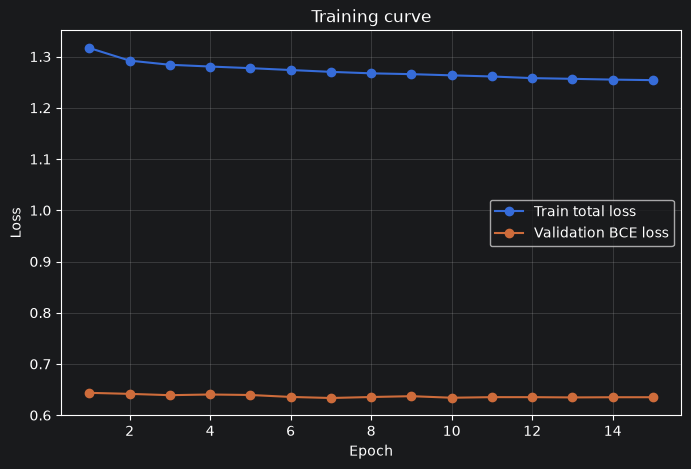

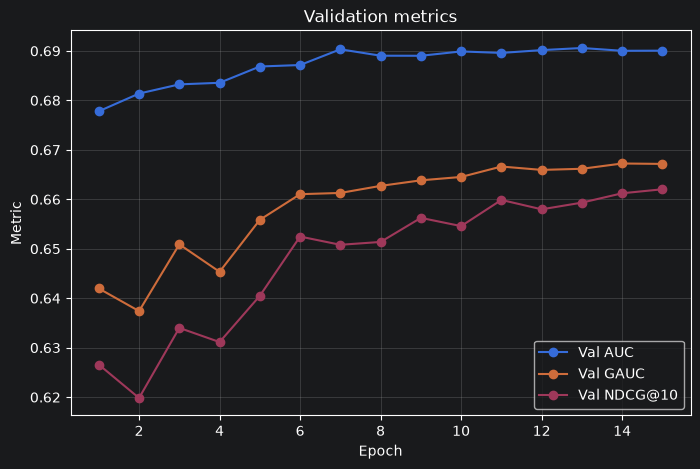

In [31]:
if experiment_results:
    history_to_plot = experiment_results[-1]["history"]
    if len(history_to_plot):
        plt.figure(figsize=(8, 5))
        plt.plot(
            history_to_plot["epoch"],
            history_to_plot["train_total_loss"],
            marker="o",
            label="Train total loss",
        )
        plt.plot(
            history_to_plot["epoch"],
            history_to_plot["val_loss"],
            marker="o",
            label="Validation BCE loss",
        )
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training curve")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(
            history_to_plot["epoch"],
            history_to_plot["val_auc"],
            marker="o",
            label="Val AUC",
        )
        plt.plot(
            history_to_plot["epoch"],
            history_to_plot["val_gauc"],
            marker="o",
            label="Val GAUC",
        )
        plt.plot(
            history_to_plot["epoch"],
            history_to_plot["val_ndcg_at_10"],
            marker="o",
            label="Val NDCG@10",
        )
        plt.xlabel("Epoch")
        plt.ylabel("Metric")
        plt.title("Validation metrics")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

In [32]:
def normalized_attention_entropy(
    weights: torch.Tensor,
    query_mask: torch.Tensor,
    key_mask: torch.Tensor,
) -> float:
    probability = weights.float().clamp_min(1e-12)
    entropy = -(probability * probability.log()).sum(dim=-1)
    valid_key_count = key_mask.sum(dim=-1).clamp_min(2).float()
    normalized = entropy / valid_key_count.log().view(-1, 1, 1)
    valid_query = query_mask.unsqueeze(1).expand_as(normalized)
    values = normalized[valid_query]
    return float(values.mean().item()) if values.numel() else float("nan")

def masked_attention_mean_matrix(
    weights: torch.Tensor,
    query_mask: torch.Tensor,
    key_mask: torch.Tensor,
) -> np.ndarray:
    valid = (
        query_mask[:, None, :, None]
        & key_mask[:, None, None, :]
    )
    weighted_sum = (
        weights.float() * valid.to(weights.dtype)
    ).sum(dim=(0, 1))
    denominator = valid.sum(dim=(0, 1)).clamp_min(1)
    return (weighted_sum / denominator).cpu().numpy()

def masked_gate_mean(
    gates: torch.Tensor,
    mask: torch.Tensor,
) -> np.ndarray:
    numerator = (gates.float() * mask.float()).sum(dim=0)
    denominator = mask.sum(dim=0).clamp_min(1)
    return (numerator / denominator).cpu().numpy()

def history_entropy(
    weights: torch.Tensor,
    mask: torch.Tensor,
) -> float:
    probability = weights.float().clamp_min(1e-12)
    entropy = -(probability * probability.log()).sum(dim=-1)
    valid_count = mask.sum(dim=-1).clamp_min(2).float()
    normalized = entropy / valid_count.log()
    valid_rows = mask.any(dim=-1)
    return (
        float(normalized[valid_rows].mean().item())
        if valid_rows.any() else float("nan")
    )

if last_model is None:
    raise RuntimeError("请先运行正式训练 Cell")

last_model.eval()
diagnostic_batch = move_batch_to_device(next(iter(loaders["test"])))
with torch.no_grad():
    diagnostic_output = last_model(
        diagnostic_batch, return_attention=True
    )

user_field_names = [
    *USER_CATEGORY_FIELDS,
    *USER_NUMERIC_FIELDS,
    *HISTORY_TEXT_FIELD_NAMES,
]
item_field_names = [
    *ITEM_CATEGORY_FIELDS,
    *ITEM_NUMERIC_FIELDS,
    "tag",
    *TEXT_FIELD_NAMES,
]

diagnostics = {
    "user_field_count": len(user_field_names),
    "item_field_count": len(item_field_names),
    "history_attention_entropy": history_entropy(
        diagnostic_output["history_attention"],
        diagnostic_batch["history_mask"],
    ),
    "history_max_weight": float(
        diagnostic_output["history_attention"].float().max().item()
    ),
}

user_gate_mean = masked_gate_mean(
    diagnostic_output["user_gates"],
    diagnostic_output["user_mask"],
)
item_gate_mean = masked_gate_mean(
    diagnostic_output["item_gates"],
    diagnostic_output["item_mask"],
)
pd.DataFrame({
    "field": user_field_names,
    "mean_gate": user_gate_mean,
}).to_csv(last_run_dir / "user_field_gate_mean.csv", index=False)
pd.DataFrame({
    "field": item_field_names,
    "mean_gate": item_gate_mean,
}).to_csv(last_run_dir / "item_field_gate_mean.csv", index=False)

for layer_index, weights in enumerate(
    diagnostic_output["user_self_attention"], start=1
):
    diagnostics[f"user_self_layer{layer_index}_entropy"] = (
        normalized_attention_entropy(
            weights,
            diagnostic_output["user_mask"],
            diagnostic_output["user_mask"],
        )
    )
    diagnostics[f"user_self_layer{layer_index}_max_weight"] = float(
        weights.float().max().item()
    )

for layer_index, weights in enumerate(
    diagnostic_output["item_self_attention"], start=1
):
    diagnostics[f"item_self_layer{layer_index}_entropy"] = (
        normalized_attention_entropy(
            weights,
            diagnostic_output["item_mask"],
            diagnostic_output["item_mask"],
        )
    )
    diagnostics[f"item_self_layer{layer_index}_max_weight"] = float(
        weights.float().max().item()
    )

for direction in ["u2i", "i2u"]:
    weights_list = diagnostic_output["cross_attention"][direction]
    for layer_index, weights in enumerate(weights_list, start=1):
        if direction == "u2i":
            query_mask = diagnostic_output["user_mask"]
            key_mask = diagnostic_output["item_mask"]
            row_names = user_field_names
            column_names = item_field_names
        else:
            query_mask = diagnostic_output["item_mask"]
            key_mask = diagnostic_output["user_mask"]
            row_names = item_field_names
            column_names = user_field_names

        diagnostics[f"{direction}_layer{layer_index}_entropy"] = (
            normalized_attention_entropy(
                weights, query_mask, key_mask
            )
        )
        diagnostics[f"{direction}_layer{layer_index}_max_weight"] = float(
            weights.float().max().item()
        )

        matrix = masked_attention_mean_matrix(
            weights, query_mask, key_mask
        )
        frame = pd.DataFrame(
            matrix,
            index=row_names,
            columns=column_names,
        )
        frame.to_csv(
            last_run_dir / f"attention_{direction}_layer{layer_index}.csv"
        )

(last_run_dir / "attention_diagnostics.json").write_text(
    json.dumps(diagnostics, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print(json.dumps(diagnostics, ensure_ascii=False, indent=2))

{
  "user_field_count": 32,
  "item_field_count": 16,
  "history_attention_entropy": 0.9069239497184753,
  "history_max_weight": 0.2261829674243927,
  "user_self_layer1_entropy": 0.6788144111633301,
  "user_self_layer1_max_weight": 0.8721721768379211,
  "user_self_layer2_entropy": 0.8003628253936768,
  "user_self_layer2_max_weight": 0.8419182896614075,
  "item_self_layer1_entropy": 0.6002163290977478,
  "item_self_layer1_max_weight": 0.9783723950386047,
  "item_self_layer2_entropy": 0.6871153712272644,
  "item_self_layer2_max_weight": 0.9985779523849487,
  "u2i_layer1_entropy": 0.686485230922699,
  "u2i_layer1_max_weight": 0.9992316961288452,
  "i2u_layer1_entropy": 0.8100407123565674,
  "i2u_layer1_max_weight": 0.2744388282299042
}


In [33]:
known_interactions = pd.concat(
    [train_log, val_log],
    ignore_index=True,
).sort_values(
    ["user_index", "event_time_ms"], kind="mergesort"
)

def build_latest_history_for_user(
    user_index: int,
    max_history: int,
):
    group = known_interactions[
        known_interactions["user_index"].eq(user_index)
    ].tail(max_history)

    history_items = np.zeros(max_history, dtype=np.int64)
    history_feedback = np.zeros(
        (max_history, len(HISTORY_FEEDBACK_COLUMNS)),
        dtype=np.float32,
    )
    history_delta_time = np.zeros((max_history, 1), dtype=np.float32)
    history_engagement = np.zeros(max_history, dtype=np.float32)
    history_strong_action = np.zeros(max_history, dtype=np.float32)
    history_mask = np.zeros(max_history, dtype=bool)

    if len(group):
        length = len(group)
        destination = slice(max_history - length, max_history)
        history_items[destination] = group["item_index"].to_numpy(np.int64)
        history_feedback[destination] = group[
            HISTORY_FEEDBACK_COLUMNS
        ].to_numpy(np.float32)
        history_engagement[destination] = group[
            "engagement"
        ].to_numpy(np.float32)
        history_strong_action[destination] = group[
            "strong_action"
        ].to_numpy(np.float32)

        current_time = int(group["event_time_ms"].max()) + 1
        delta_hours = (
            (current_time - group["event_time_ms"].to_numpy(np.int64))
            / (1000 * 60 * 60)
        ).clip(min=0)
        history_delta_time[destination, 0] = np.log1p(
            delta_hours
        ).astype(np.float32)
        history_mask[destination] = True

    return {
        "history_item_indices": history_items,
        "history_feedback": history_feedback,
        "history_delta_time": history_delta_time,
        "history_engagement": history_engagement,
        "history_strong_action": history_strong_action,
        "history_mask": history_mask,
    }

@torch.inference_mode()
def recommend_top_k(
    model: nn.Module,
    user_id: int,
    top_k: int = 20,
    candidate_video_ids: list[int] | None = None,
    exclude_seen: bool = True,
    score_batch_size: int = 512,
) -> pd.DataFrame:
    if int(user_id) not in user_id_to_index:
        raise KeyError(f"user_id={user_id} 不在当前用户映射中")
    user_index = int(user_id_to_index[int(user_id)])

    if candidate_video_ids is None:
        candidate_indices = np.arange(1, len(index_to_video_id), dtype=np.int64)
    else:
        candidate_indices = np.asarray([
            video_id_to_index[int(video_id)]
            for video_id in candidate_video_ids
            if int(video_id) in video_id_to_index
        ], dtype=np.int64)

    if exclude_seen:
        seen = set(
            known_interactions.loc[
                known_interactions["user_index"].eq(user_index),
                "item_index",
            ].astype("int64").tolist()
        )
        candidate_indices = np.asarray(
            [idx for idx in candidate_indices if int(idx) not in seen],
            dtype=np.int64,
        )

    if len(candidate_indices) == 0:
        return pd.DataFrame(columns=["video_id", "score"])

    history = build_latest_history_for_user(
        user_index, CFG.MAX_HISTORY
    )
    all_scores = []
    model.eval()

    for start in range(0, len(candidate_indices), score_batch_size):
        batch_items = candidate_indices[start:start + score_batch_size]
        batch_size = len(batch_items)

        batch = {
            "user_index": torch.full(
                (batch_size,), user_index, dtype=torch.long
            ),
            "candidate_item_index": torch.from_numpy(batch_items).long(),
            "history_item_indices": torch.from_numpy(
                np.repeat(
                    history["history_item_indices"][None, :],
                    batch_size,
                    axis=0,
                )
            ).long(),
            "history_feedback": torch.from_numpy(
                np.repeat(
                    history["history_feedback"][None, :, :],
                    batch_size,
                    axis=0,
                )
            ).float(),
            "history_delta_time": torch.from_numpy(
                np.repeat(
                    history["history_delta_time"][None, :, :],
                    batch_size,
                    axis=0,
                )
            ).float(),
            "history_engagement": torch.from_numpy(
                np.repeat(
                    history["history_engagement"][None, :],
                    batch_size,
                    axis=0,
                )
            ).float(),
            "history_strong_action": torch.from_numpy(
                np.repeat(
                    history["history_strong_action"][None, :],
                    batch_size,
                    axis=0,
                )
            ).float(),
            "history_mask": torch.from_numpy(
                np.repeat(
                    history["history_mask"][None, :],
                    batch_size,
                    axis=0,
                )
            ).bool(),
            "label": torch.zeros(batch_size, dtype=torch.float32),
            "strong_action_label": torch.zeros(
                batch_size, dtype=torch.float32
            ),
            "long_view_label": torch.zeros(
                batch_size, dtype=torch.float32
            ),
            "click_label": torch.zeros(
                batch_size, dtype=torch.float32
            ),
        }
        batch = move_batch_to_device(batch)

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=AMP_DTYPE,
            enabled=USE_AMP,
        ):
            output = model(batch)
        all_scores.append(
            torch.sigmoid(output["logits"].float()).cpu().numpy()
        )

    scores = np.concatenate(all_scores)
    order = np.argsort(-scores, kind="stable")[:top_k]
    selected_indices = candidate_indices[order]

    result = pd.DataFrame({
        "video_id": index_to_video_id[selected_indices],
        "score": scores[order],
    })
    return result

# 使用示例：
# example_user_id = int(index_to_user_id[0])
# top_items = recommend_top_k(last_model, example_user_id, top_k=20)
# display(top_items)

In [34]:
# 推荐执行顺序：
#
# 1. 修改 Config.DATA_DIR。
# 2. 首次将 DEBUG_MODE=True、SEEDS=(2026,)，Run All。
# 3. 确认：
#    - Caption/Category 覆盖率正常；
#    - Shape Sanity Check 无 NaN；
#    - 小样本 Overfit 能明显下降；
#    - Debug 训练能生成 best_model.pt 和 metrics.json。
# 4. Restart Kernel。
# 5. DEBUG_MODE=False，先跑：
#       MODEL_MODE="paper_no_id"
#       SEEDS=(2026,)
# 6. 结果稳定后补跑：
#       SEEDS=(2026, 2027, 2028)
# 7. 再切换：
#       MODEL_MODE="hybrid_max_accuracy"
#    作为实际落地最高准确率版本。
# 8. Random Test 只用于最终报告，不依据 Random Test 调参数。
#
# 正式论文至少报告：
# - AUC / GAUC
# - NDCG@5/10/20
# - Recall@5/10/20
# - HitRate@5/10/20
# - Val 与 Random Test 的性能差距
# - Self-Attention / Cross-Attention entropy、max weight
# - 三随机种子 mean ± std
#
# 第一轮若显存不足，优先按顺序调整：
# BATCH_SIZE 128 -> 64
# MACBERT_BATCH_SIZE 96 -> 48
# D_MODEL 512 保持不变
#
# 训练速度慢但显存充足时：
# NUM_WORKERS 0 -> 4（Windows/Jupyter 需先确认不会报多进程错误）

In [35]:
# ============================================================
# Phase 2: Two-Stage Debiasing - Data Preparation
# ============================================================
# Split random exposure log by date, rebuild sequences,
# and create DataLoaders for Phase 2 fine-tuning.
#
# random_train: 2026-06-23 ~ 2026-07-21 (~47w, pos rate ~17%)
# random_val:   2026-07-22 ~ 2026-08-11 (~72w)

PHASE2_RUN_TAG = "sfg_bicross_p2_debias"
PHASE2_SPLIT_DATE = "20260722"
PHASE2_LR = 1e-5
PHASE2_EPOCHS = 5
PHASE2_EARLY_STOPPING_PATIENCE = 2

# Split test_log by date
test_log_p2 = test_log.copy()
# date is int64 like 20220422 (YYYYMMDD) from clean_log.
# pd.to_datetime on int gives nanoseconds-since-epoch, NOT YYYYMMDD.
# Convert to string, then parse as YYYYMMDD.
test_log_p2["_date_parsed"] = pd.to_datetime(
    test_log_p2["date"].astype(str), format="%Y%m%d"
)
test_log_p2["split"] = np.where(
    test_log_p2["_date_parsed"] < PHASE2_SPLIT_DATE,
    "random_train",
    "random_val",
)
test_log_p2.drop(columns=["_date_parsed"], inplace=True)

n_rt = (test_log_p2["split"] == "random_train").sum()
n_rv = (test_log_p2["split"] == "random_val").sum()
rt_pos = test_log_p2.loc[test_log_p2["split"] == "random_train", "engagement"].mean()
rv_pos = test_log_p2.loc[test_log_p2["split"] == "random_val", "engagement"].mean()
print("random_train:", n_rt, "rows  pos_rate:", round(rt_pos, 4))
print("random_val:  ", n_rv, "rows  pos_rate:", round(rv_pos, 4))

# Build Phase 2 events frame (train log + random log, time-sorted)
p2_events = pd.concat([train_log, test_log_p2], ignore_index=True)
p2_split_map = {"train": 0, "random_train": 1, "random_val": 2}
p2_events["split_code"] = p2_events["split"].map(p2_split_map).astype("int8")
p2_events["_p2_order"] = np.arange(len(p2_events), dtype=np.int64)
p2_events = (
    p2_events.sort_values(
        ["user_index", "event_time_ms", "_p2_order"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

# Build Phase 2 user sequences
p2_allowed_history = {
    "random_train": np.array([0, 1], dtype=np.int8),
    "random_val": np.array([0, 1, 2], dtype=np.int8),
}

def build_p2_sequences(events_frame):
    sequences = {}
    target_chunks = {"random_train": [], "random_val": []}
    pos_chunks = {"random_train": [], "random_val": []}

    grouped = events_frame.groupby("user_index", sort=False)
    for user_index, group in tqdm(grouped, total=grouped.ngroups, desc="Phase2 sequences"):
        group = group.reset_index(drop=True)
        positions = np.arange(len(group), dtype=np.int32)
        split_codes = group["split_code"].to_numpy(np.int8)

        seq = {
            "item_index": group["item_index"].to_numpy(np.int32),
            "event_time_ms": group["event_time_ms"].to_numpy(np.int64),
            "feedback": group[HISTORY_FEEDBACK_COLUMNS].to_numpy(np.float32),
            "engagement": group["engagement"].to_numpy(np.float32),
            "strong_action": group["strong_action"].to_numpy(np.float32),
            "long_view": group["long_view"].to_numpy(np.float32),
            "is_click": group["is_click"].to_numpy(np.float32),
            "split_code": split_codes,
        }
        for split_name, allowed in p2_allowed_history.items():
            seq["history_positions_" + split_name] = positions[
                np.isin(split_codes, allowed)
            ]
        sequences[int(user_index)] = seq

        for split_name in ("random_train", "random_val"):
            sc = p2_split_map[split_name]
            mask = split_codes == sc
            if mask.any():
                target_chunks[split_name].append(
                    np.full(mask.sum(), int(user_index), dtype=np.int32)
                )
                pos_chunks[split_name].append(positions[mask])

    targets = {}
    for split_name in ("random_train", "random_val"):
        if target_chunks[split_name]:
            targets[split_name] = (
                np.concatenate(target_chunks[split_name]),
                np.concatenate(pos_chunks[split_name]),
            )
        else:
            targets[split_name] = (
                np.zeros(0, dtype=np.int32),
                np.zeros(0, dtype=np.int32),
            )
            print(
                "WARNING: no", split_name, "targets found in p2_events. "
                "Check that active users have random log events in this date range."
            )
    return sequences, targets

p2_sequences, p2_targets = build_p2_sequences(p2_events)
for name in ("random_train", "random_val"):
    print("  ", name, len(p2_targets[name][0]), "targets  users:", np.unique(p2_targets[name][0]).size)

# Create Phase 2 DataLoaders
if len(p2_targets["random_train"][0]) == 0:
    raise RuntimeError(
        "No random_train targets. Phase 2 cannot proceed. "
        "Check that active users have random-log events before "
        + PHASE2_SPLIT_DATE
    )
if len(p2_targets["random_val"][0]) == 0:
    raise RuntimeError(
        "No random_val targets. Phase 2 cannot proceed."
    )

p2_random_train_dataset = SequentialExposureDataset(
    p2_sequences,
    p2_targets["random_train"][0],
    p2_targets["random_train"][1],
    CFG.MAX_HISTORY,
    "random_train",
)
p2_random_val_dataset = SequentialExposureDataset(
    p2_sequences,
    p2_targets["random_val"][0],
    p2_targets["random_val"][1],
    CFG.MAX_HISTORY,
    "random_val",
)
print("random_train dataset:", len(p2_random_train_dataset))
print("random_val dataset:  ", len(p2_random_val_dataset))

loader_kwargs = dict(
    num_workers=CFG.NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=False,
)
p2_train_sampler = UserGroupedBatchSampler(
    p2_random_train_dataset.target_users,
    CFG.BATCH_SIZE,
    CFG.TRAIN_EVENTS_PER_USER_PER_BATCH,
    CFG.SEEDS[0],
)
p2_loaders = {
    "random_train": DataLoader(
        p2_random_train_dataset,
        batch_sampler=p2_train_sampler,
        **loader_kwargs,
    ),
    "random_val": DataLoader(
        p2_random_val_dataset,
        batch_size=CFG.BATCH_SIZE * 4,
        shuffle=False,
        drop_last=False,
        **loader_kwargs,
    ),
}
print("Phase 2 DataLoaders ready")


random_train: 35449 rows  pos_rate: 0.177
random_val:   24319 rows  pos_rate: 0.1781


Phase2 sequences: 100%|██████████| 2992/2992 [00:01<00:00, 1660.18it/s]

   random_train 35449 targets  users: 2992
   random_val 24319 targets  users: 2992
random_train dataset: 35449
random_val dataset:   24319
Phase 2 DataLoaders ready


In [36]:
# ============================================================
# Phase 2: Two-Stage Debiasing - Training
# ============================================================
# Load Phase 1 best checkpoint, freeze bottom layers
# (FieldTokenEncoder), fine-tune upper layers on random
# exposure data to reduce exposure gap.
#
# Standalone - reads Phase 1 checkpoint from disk, no
# dependency on Phase 1 kernel variables.

# Locate Phase 1 checkpoint
_P1_RUN_NAME = (
    "sfg_bicross_final_" + CFG.MODEL_MODE
    + "_d" + str(CFG.D_MODEL) + "_h" + str(CFG.NUM_HEADS)
    + "_self" + str(CFG.SELF_ATTENTION_LAYERS)
    + "_cross" + str(CFG.CROSS_ATTENTION_LAYERS)
    + "_seed" + str(CFG.SEEDS[0])
)
_P1_RUN_DIR = CFG.OUTPUT_ROOT / _P1_RUN_NAME
phase1_ckpt_path = _P1_RUN_DIR / "best_model.pt"
phase1_metrics_path = _P1_RUN_DIR / "metrics.json"

if not phase1_ckpt_path.exists():
    raise FileNotFoundError(
        "Phase 1 checkpoint not found: " + str(phase1_ckpt_path)
    )
print("Phase 1 checkpoint:", str(phase1_ckpt_path))

# Load Phase 1 baseline metrics for comparison
if phase1_metrics_path.exists():
    p1_raw = json.loads(phase1_metrics_path.read_text(encoding="utf-8"))
    p1_val_ndcg = p1_raw["validation"]["event_ranking"]["NDCG@10"]
    p1_val_auc = p1_raw["validation"]["auc"]
    p1_test_ndcg = p1_raw["random_test"]["event_ranking"]["NDCG@10"]
    p1_test_auc = p1_raw["random_test"]["auc"]
    p1_test_hitrate = p1_raw["random_test"]["event_ranking"]["HitRate@10"]
    p1_gap = p1_raw.get("exposure_policy_generalization_gap_ndcg10", float("nan"))
    p1_best_epoch = p1_raw.get("best_epoch", "?")
    print("Phase 1 baseline loaded: best_epoch =", p1_best_epoch)
else:
    p1_val_ndcg = p1_val_auc = p1_test_ndcg = p1_test_auc = float("nan")
    p1_test_hitrate = p1_gap = float("nan")
    p1_best_epoch = "?"
    print("WARNING: Phase 1 metrics.json not found")

# Setup Phase 2 run dir
p2_run_name = (
    PHASE2_RUN_TAG + "_" + CFG.MODEL_MODE
    + "_d" + str(CFG.D_MODEL) + "_h" + str(CFG.NUM_HEADS)
    + "_self" + str(CFG.SELF_ATTENTION_LAYERS)
    + "_cross" + str(CFG.CROSS_ATTENTION_LAYERS)
    + "_seed" + str(CFG.SEEDS[0])
)
p2_run_dir = CFG.OUTPUT_ROOT / p2_run_name
p2_run_dir.mkdir(parents=True, exist_ok=True)

# Load Phase 1 checkpoint
p2_ckpt = torch.load(phase1_ckpt_path, map_location=DEVICE, weights_only=False)
print("Phase 1 best epoch in ckpt:", p2_ckpt.get("best_epoch", "?"))

# Create model and load Phase 1 weights
set_global_seed(CFG.SEEDS[0])
p2_model = create_model(CFG.SEEDS[0])
p2_model.load_state_dict(p2_ckpt["model_state_dict"])
p2_model.to(DEVICE)

# Freeze bottom layers
FREEZE_PREFIXES = [
    "user_encoder",
    "item_encoder",
    "history_field_embedding",
]

for name, param in p2_model.named_parameters():
    if any(name.startswith(pfx) for pfx in FREEZE_PREFIXES):
        param.requires_grad = False

trainable = sum(p.numel() for p in p2_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in p2_model.parameters())
pct = round(100 * trainable / total, 1)
print("Trainable:", trainable, "/", total, "(", pct, "%)")
print("Frozen:", FREEZE_PREFIXES)

# Phase 2 optimizer
p2_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, p2_model.parameters()),
    lr=PHASE2_LR,
    weight_decay=CFG.WEIGHT_DECAY,
)

p2_epochs = CFG.DEBUG_EPOCHS if CFG.DEBUG_MODE else PHASE2_EPOCHS
p2_steps_per_epoch = math.ceil(
    len(p2_loaders["random_train"]) / CFG.GRADIENT_ACCUMULATION_STEPS
)
p2_total_steps = max(1, p2_epochs * p2_steps_per_epoch)
p2_warmup_steps = int(p2_total_steps * CFG.WARMUP_RATIO)
p2_scheduler = get_cosine_schedule_with_warmup(
    p2_optimizer,
    num_warmup_steps=p2_warmup_steps,
    num_training_steps=p2_total_steps,
)

use_scaler = USE_AMP and AMP_DTYPE == torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=use_scaler)

p2_best_metric = -float("inf")
p2_best_epoch = -1
p2_patience = 0
p2_history = []
p2_ckpt_path = p2_run_dir / "best_model.pt"
p2_started_at = time.time()

# Phase 2 training loop
for epoch in range(1, p2_epochs + 1):
    p2_train_sampler.set_epoch(epoch)
    p2_model.train()
    p2_optimizer.zero_grad(set_to_none=True)

    running_loss = 0.0
    running_count = 0

    desc = "P2 S" + str(CFG.SEEDS[0]) + " E" + str(epoch) + "/" + str(p2_epochs)
    progress = tqdm(
        enumerate(p2_loaders["random_train"], start=1),
        total=len(p2_loaders["random_train"]),
        desc=desc,
    )

    for step, batch in progress:
        batch = move_batch_to_device(batch)
        with torch.autocast(
            device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP
        ):
            output = p2_model(batch)
            loss, loss_parts = compute_training_loss(output, batch)
            scaled_loss = loss / CFG.GRADIENT_ACCUMULATION_STEPS

        if not torch.isfinite(loss):
            msg = "Non-finite loss at p2 epoch=" + str(epoch) + " step=" + str(step)
            raise FloatingPointError(msg)

        if use_scaler:
            scaler.scale(scaled_loss).backward()
        else:
            scaled_loss.backward()

        should_step = (
            step % CFG.GRADIENT_ACCUMULATION_STEPS == 0
            or step == len(p2_loaders["random_train"])
        )
        if should_step:
            if use_scaler:
                scaler.unscale_(p2_optimizer)
            torch.nn.utils.clip_grad_norm_(
                p2_model.parameters(), CFG.GRADIENT_CLIP_NORM
            )
            if use_scaler:
                scaler.step(p2_optimizer)
                scaler.update()
            else:
                p2_optimizer.step()
            p2_scheduler.step()
            p2_optimizer.zero_grad(set_to_none=True)

        bs = batch["label"].size(0)
        running_loss += float(loss.item()) * bs
        running_count += bs

        progress.set_postfix(
            loss=running_loss / max(running_count, 1),
            lr=p2_optimizer.param_groups[0]["lr"],
        )

    train_loss = running_loss / max(running_count, 1)

    # Validate on random_val
    p2_val_result = evaluate_model(p2_model, p2_loaders["random_val"])
    p2_val_report = build_full_metric_report(p2_val_result)
    primary_value = float(p2_val_report["event_ranking"][CFG.PRIMARY_METRIC])

    p2_record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": p2_val_report["loss"],
        "val_auc": p2_val_report["auc"],
        "val_gauc": p2_val_report["event_ranking"]["GAUC"],
        "val_ndcg_at_10": p2_val_report["event_ranking"]["NDCG@10"],
        "val_recall_at_10": p2_val_report["event_ranking"]["Recall@10"],
        "val_hitrate_at_10": p2_val_report["event_ranking"]["HitRate@10"],
        "learning_rate": p2_optimizer.param_groups[0]["lr"],
        "elapsed_minutes": (time.time() - p2_started_at) / 60,
    }
    p2_history.append(p2_record)

    print(
        "P2 Epoch=", epoch,
        "train_loss=", round(train_loss, 5),
        "val_auc=", round(p2_val_report["auc"], 5),
        CFG.PRIMARY_METRIC, "=", round(primary_value, 5),
    )

    improved = (
        np.isfinite(primary_value)
        and primary_value > p2_best_metric + CFG.EARLY_STOPPING_MIN_DELTA
    )
    if improved:
        p2_best_metric = primary_value
        p2_best_epoch = epoch
        p2_patience = 0
        torch.save(
            {
                "model_state_dict": p2_model.state_dict(),
                "phase1_checkpoint": str(phase1_ckpt_path),
                "best_epoch": p2_best_epoch,
                "best_val_metric": p2_best_metric,
                "phase2_config": {
                    "split_date": PHASE2_SPLIT_DATE,
                    "lr": PHASE2_LR,
                    "epochs": PHASE2_EPOCHS,
                    "frozen_layers": FREEZE_PREFIXES,
                },
            },
            p2_ckpt_path,
        )
        print("Saved:", p2_ckpt_path.name)
    else:
        p2_patience += 1
        if p2_patience >= PHASE2_EARLY_STOPPING_PATIENCE:
            print("Early stopping at epoch", epoch)
            break

# Final evaluation
p2_history_frame = pd.DataFrame(p2_history)
p2_history_frame.to_csv(p2_run_dir / "training_history.csv", index=False)

p2_ckpt = torch.load(p2_ckpt_path, map_location=DEVICE, weights_only=False)
p2_model.load_state_dict(p2_ckpt["model_state_dict"])
p2_model.eval()

# Random val (random exposure, later dates)
p2_val_result = evaluate_model(p2_model, p2_loaders["random_val"])
p2_val_report = build_full_metric_report(p2_val_result)

# Original random test (for comparison with Phase 1)
p2_test_result = evaluate_model(p2_model, loaders["test"])
p2_test_report = build_full_metric_report(p2_test_result)

p2_val_ndcg = float(p2_val_report["event_ranking"]["NDCG@10"])
p2_test_ndcg = float(p2_test_report["event_ranking"]["NDCG@10"])

if abs(p2_val_ndcg) >= 1e-8:
    p2_exposure_gap = (p2_val_ndcg - p2_test_ndcg) / abs(p2_val_ndcg)
else:
    p2_exposure_gap = float("nan")

p2_metrics = {
    "phase": 2,
    "run_name": p2_run_name,
    "phase1_run": str(_P1_RUN_DIR),
    "seed": CFG.SEEDS[0],
    "model_mode": CFG.MODEL_MODE,
    "trainable_parameters": int(trainable),
    "frozen_layers": [str(p) for p in FREEZE_PREFIXES],
    "best_epoch": int(p2_ckpt["best_epoch"]),
    "best_val_metric": float(p2_ckpt["best_val_metric"]),
    "random_train_val": p2_val_report,
    "random_test": p2_test_report,
    "exposure_gap_p2": float(p2_exposure_gap),
}

(p2_run_dir / "metrics.json").write_text(
    json.dumps(p2_metrics, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print()
print("=" * 60)
print("Phase 2 Results (Random Exposure Fine-tuning)")
print("=" * 60)
print("Best epoch:", p2_best_epoch)
print("Random Val:  NDCG@10 =", round(p2_val_ndcg, 4),
      " AUC =", round(p2_val_report["auc"], 4),
      " HitRate@10 =", round(p2_val_report["event_ranking"]["HitRate@10"], 4))
print("Random Test: NDCG@10 =", round(p2_test_ndcg, 4),
      " AUC =", round(p2_test_report["auc"], 4),
      " HitRate@10 =", round(p2_test_report["event_ranking"]["HitRate@10"], 4))
print("Exposure Gap (p2):", round(p2_exposure_gap, 4))

print()
print("--- Phase 1 Baseline ---")
print("Best epoch:", p1_best_epoch)
print("Val    NDCG@10:", round(p1_val_ndcg, 4), " AUC:", round(p1_val_auc, 4))
print("Random NDCG@10:", round(p1_test_ndcg, 4),
      " AUC:", round(p1_test_auc, 4),
      " HitRate:", round(p1_test_hitrate, 4))
print("Exposure Gap:   ", round(p1_gap, 4) if np.isfinite(p1_gap) else "nan")

print()
print("--- Delta (P2 - P1) ---")
print("Random NDCG@10:", round(p2_test_ndcg - p1_test_ndcg, 4))
print("Random AUC:    ", round(p2_test_report["auc"] - p1_test_auc, 4))
if np.isfinite(p1_gap):
    print("Exposure Gap:  ", round(p2_exposure_gap - p1_gap, 4))
else:
    print("Exposure Gap:   N/A")


Phase 1 checkpoint: D:\dev\projects\datasets_collection\outputs_sfg_bicross\sfg_bicross_final_paper_no_id_d512_h8_self2_cross1_seed2026\best_model.pt
Phase 1 baseline loaded: best_epoch = 15
Phase 1 best epoch in ckpt: 15
Trainable: 28061557 / 29685749 ( 94.5 %)
Frozen: ['user_encoder', 'item_encoder', 'history_field_embedding']


P2 S2026 E1/5: 100%|██████████| 786/786 [00:47<00:00, 16.70it/s, loss=1.05, lr=9.4e-6] 


P2 Epoch= 1 train_loss= 1.05464 val_auc= 0.6054 NDCG@10 = 0.62553
Saved: best_model.pt


P2 S2026 E2/5: 100%|██████████| 786/786 [00:45<00:00, 17.37it/s, loss=0.902, lr=7.01e-6]


P2 Epoch= 2 train_loss= 0.90156 val_auc= 0.61123 NDCG@10 = 0.62604
Saved: best_model.pt


...

P2 S2026 E4/5: 100%|██████████| 786/786 [00:49<00:00, 15.95it/s, loss=0.894, lr=1.05e-6]


P2 Epoch= 4 train_loss= 0.89449 val_auc= 0.6174 NDCG@10 = 0.63168
Saved: best_model.pt


P2 S2026 E5/5: 100%|██████████| 786/786 [00:45<00:00, 17.41it/s, loss=0.893, lr=0]       


P2 Epoch= 5 train_loss= 0.89338 val_auc= 0.6175 NDCG@10 = 0.63076



Phase 2 Results (Random Exposure Fine-tuning)
Best epoch: 4
Random Val:  NDCG@10 = 0.6317  AUC = 0.6174  HitRate@10 = 0.993
Random Test: NDCG@10 = 0.4326  AUC = 0.6247  HitRate@10 = 0.93
Exposure Gap (p2): 0.3152

--- Phase 1 Baseline ---
Best epoch: 15
Val    NDCG@10: 0.662  AUC: 0.69
Random NDCG@10: 0.4269  AUC: 0.6154  HitRate: 0.9245
Exposure Gap:    0.3552

--- Delta (P2 - P1) ---
Random NDCG@10: 0.0057
Random AUC:     0.0094
Exposure Gap:   -0.04


In [37]:
# ============================================================
# P1 vs P2 on the same clean random_val set
# ============================================================
# Both tested on p2_loaders["random_val"] (2022-05-01 ~ 2022-05-08).
# P1 never saw any random data during training,
# P2 trained on random_train (2022-04-22 ~ 2022-04-30),
# neither saw random_val. Fair comparison.

# Load Phase 1 model
p1_for_compare = create_model(CFG.SEEDS[0])
p1_ckpt = torch.load(phase1_ckpt_path, map_location=DEVICE, weights_only=False)
p1_for_compare.load_state_dict(p1_ckpt["model_state_dict"])
p1_for_compare.to(DEVICE)
p1_for_compare.eval()

# Evaluate on the same random_val set
p1_randval_result = evaluate_model(p1_for_compare, p2_loaders["random_val"])
p1_randval_report = build_full_metric_report(p1_randval_result)

# P2 result already computed in Cell[35] as p2_val_report

print()
print("=" * 70)
print("P1 vs P2 on the same clean test set (random_val: 2022-05-01~08)")
print("=" * 70)
print()
print("                    P1          P2        Delta")
print("-" * 55)
metrics_to_show = [
    ("NDCG@10",  "event_ranking", "NDCG@10"),
    ("Recall@10", "event_ranking", "Recall@10"),
    ("HitRate@10","event_ranking", "HitRate@10"),
    ("AUC",       None,            "auc"),
    ("GAUC",      "event_ranking", "GAUC"),
]
for label, section, key in metrics_to_show:
    if section:
        v1 = p1_randval_report[section][key]
        v2 = p2_val_report[section][key]
    else:
        v1 = p1_randval_report[key]
        v2 = p2_val_report[key]
    delta = v2 - v1
    sign = "+" if delta >= 0 else ""
    print(f"  {label:>11}:  {v1:>8.4f}   {v2:>8.4f}   {sign}{delta:.4f}")

print()
print("P1 random_val NDCG@10:", round(p1_randval_report["event_ranking"]["NDCG@10"], 4))
print("P2 random_val NDCG@10:", round(p2_val_report["event_ranking"]["NDCG@10"], 4))

# Clean up
del p1_for_compare, p1_ckpt
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()



P1 vs P2 on the same clean test set (random_val: 2022-05-01~08)

                    P1          P2        Delta
-------------------------------------------------------
      NDCG@10:    0.6232     0.6317   +0.0085
    Recall@10:    0.9746     0.9773   +0.0027
   HitRate@10:    0.9917     0.9930   +0.0013
          AUC:    0.6028     0.6174   +0.0146
         GAUC:    0.5791     0.5955   +0.0164

P1 random_val NDCG@10: 0.6232
P2 random_val NDCG@10: 0.6317
